# 🌍 Global Investment Instruments — Multi-Horizon Performance Analysis

**Author:** Burak ARI | Data Scientist & Analyst  
**Website:** [burakari.com](https://burakari.com)  
**LinkedIn:** [linkedin.com/in/burakaridata](https://www.linkedin.com/in/burakaridata/)  
**GitHub:** [github.com/burakari](https://github.com/burakari)  
**Email:** burak@burakari.com

---

## 🎯 What Does This Project Answer?

Global markets offer a vast array of investment instruments.
But which ones actually deliver — across different time horizons,
risk profiles, and market cycles?

This analysis systematically answers:

1. Which instruments delivered the **highest total returns** across 1M, 1Y, 5Y, 10Y?
2. What does **risk-adjusted performance** look like (Sharpe Ratio)?
3. Which assets had the **deepest drawdowns** — how much could you lose?
4. What is the **CAGR** (Compound Annual Growth Rate) of each instrument?
5. Which assets are **correlated** — and which offer true diversification?

---

## 📦 Assets Covered

| Category | Instrument | Ticker |
|---|---|---|
| 🇺🇸 US Equities | S&P 500 | `^GSPC` |
| 💻 US Tech | NASDAQ 100 | `^NDX` |
| 🇬🇧 UK Equities | FTSE 100 | `^FTSE` |
| 🇩🇪 EU Equities | DAX | `^GDAXI` |
| 🇯🇵 Japan Equities | Nikkei 225 | `^N225` |
| 🥇 Precious Metals | Gold | `GC=F` |
| 🥈 Precious Metals | Silver | `SI=F` |
| 🛢️ Energy | Crude Oil (WTI) | `CL=F` |
| ₿ Crypto | Bitcoin | `BTC-USD` |
| 🔷 Crypto | Ethereum | `ETH-USD` |
| 💵 Currency | DXY (USD Index) | `DX-Y.NYB` |

---

## 📐 Metrics Used

| Metric | Description |
|---|---|
| **Total Return** | (Last Price / First Price - 1) × 100 |
| **CAGR** | Compound Annual Growth Rate |
| **Sharpe Ratio** | Risk-adjusted return vs risk-free rate |
| **Max Drawdown** | Largest peak-to-trough decline |
| **Volatility** | Annualized standard deviation of daily returns |

---

> ⚠️ **Disclaimer:** This analysis is for educational purposes only.
> It does not constitute financial advice.
> Past performance is not indicative of future results.

## ⚙️ Section 1: Setup & Libraries

### What is a library?
Python cannot do everything on its own. **Libraries** are pre-built
toolboxes written by others that extend Python's capabilities.

| Library | Purpose |
|---|---|
| `yfinance` | Fetches market data from Yahoo Finance automatically |
| `pandas` | Table (DataFrame) operations — think Excel in Python |
| `numpy` | Mathematical calculations and array operations |
| `matplotlib` | Creates charts and visualizations |
| `seaborn` | Advanced statistical visualizations |

### What is pip?
`pip` is Python's package manager.
`pip install package_name` installs libraries on your computer.

### Why subprocess?
Normally you install libraries in the terminal.
Using `subprocess`, we can do it **directly from the notebook** —
it installs to whichever Python environment is active,
avoiding version conflicts.

### What is a virtual environment?
An isolated Python installation for a specific project.
Prevents library version conflicts between different projects.
Think of it as a separate workspace for each project.

In [16]:
# ─────────────────────────────────────────────────────────────────
# LIBRARY INSTALLATION
#
# sys.executable → finds whichever Python is currently active
# subprocess.run → runs a terminal command from inside the notebook
# This ensures libraries install to the correct environment
# regardless of which Python or virtualenv is being used
# ─────────────────────────────────────────────────────────────────

import subprocess
import sys

libraries = [
    "yfinance",    # financial data fetching
    "pandas",      # table operations
    "numpy",       # mathematics
    "matplotlib",  # charting
    "seaborn",     # advanced visualizations
]

print("📦 Installing / verifying libraries...\n")

for lib in libraries:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "--upgrade", lib],
        capture_output=True,
        text=True
    )
    # Only show newly installed — skip already-installed ones
    if "Successfully installed" in result.stdout:
        version = [l for l in result.stdout.split('\n') 
                   if lib in l.lower() and 'installed' in l.lower()]
        print(f"  ✅ {lib:12s} — installed")
    else:
        print(f"  ✓  {lib:12s} — already up to date")

print("\n🎉 All libraries ready!")

📦 Installing / verifying libraries...

  ✓  yfinance     — already up to date
  ✓  pandas       — already up to date
  ✓  numpy        — already up to date
  ✓  matplotlib   — already up to date
  ✓  seaborn      — already up to date

🎉 All libraries ready!


## 📚 Section 2: Import Libraries & Configure Settings

### What does "import" mean?
We installed the libraries — but they're not loaded yet.
`import` loads the library **into this notebook session**
and makes it available to use.

### What does "as" mean?
`import pandas as pd` → instead of typing `pandas` every time,
call it `pd` for short. These are universal conventions:

| Full Name | Shorthand | Why? |
|---|---|---|
| `pandas` | `pd` | Universal standard |
| `numpy` | `np` | Universal standard |
| `matplotlib.pyplot` | `plt` | Universal standard |
| `seaborn` | `sns` | From the creator's favorite TV show |

### Why configure chart style?
Matplotlib's default white background looks generic.
A dark theme (`#0f0f0f`) looks more professional
and renders much better on GitHub previews and LinkedIn posts.

### What is a color palette?
We assign a fixed color to each asset.
Using the same color consistently across all charts
makes the analysis much easier to read at a glance.

In [17]:
# ─────────────────────────────────────────────────────────────────
# IMPORT LIBRARIES
#
# warnings → Python sometimes generates warning messages
# filterwarnings('ignore') → suppress them to keep output clean
# ─────────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

import pandas as pd          # table (DataFrame) operations
import numpy as np           # mathematical calculations
import matplotlib.pyplot as plt        # chart creation
import matplotlib.ticker as mticker    # axis formatting
import seaborn as sns                  # heatmaps & correlation charts
import yfinance as yf                  # Yahoo Finance data
from datetime import datetime, timedelta  # date calculations

# ─────────────────────────────────────────────────────────────────
# CHART STYLE CONFIGURATION
#
# rcParams → matplotlib's global settings dictionary
# Set once here → all charts automatically use this style
# ─────────────────────────────────────────────────────────────────

plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',   # outer background: black
    'axes.facecolor':   '#1a1a1a',   # inner background: dark grey
    'axes.edgecolor':   '#333333',   # chart border color
    'axes.labelcolor':  '#cccccc',   # axis label color
    'xtick.color':      '#888888',   # x-axis tick color
    'ytick.color':      '#888888',   # y-axis tick color
    'text.color':       '#eeeeee',   # general text color
    'grid.color':       '#2a2a2a',   # grid line color
    'grid.linestyle':   '--',        # grid line style: dashed
    'font.family':      'monospace', # font: fixed-width
    'figure.dpi':       130,         # resolution (higher = sharper)
})

# ─────────────────────────────────────────────────────────────────
# COLOR PALETTE
#
# Each asset gets a fixed, distinctive color
# Same color used across ALL charts → visual consistency
# Colors chosen to be distinguishable even in grayscale
# ─────────────────────────────────────────────────────────────────

PALETTE = {
    'SP500':   '#00d4aa',   # teal
    'NASDAQ':  '#74c0fc',   # light blue
    'FTSE':    '#a9e34b',   # green
    'DAX':     '#ffa94d',   # orange
    'NIKKEI':  '#ff6b6b',   # red
    'GOLD':    '#ffd43b',   # gold
    'SILVER':  '#ced4da',   # silver
    'OIL':     '#8b5e3c',   # brown
    'BTC':     '#f7931a',   # bitcoin orange
    'ETH':     '#627eea',   # ethereum purple
    'DXY':     '#cc5de8',   # violet
}

print("✅ Libraries imported successfully.")
print("✅ Dark theme chart style configured.")
print(f"✅ Color palette ready for {len(PALETTE)} assets.")

✅ Libraries imported successfully.
✅ Dark theme chart style configured.
✅ Color palette ready for 11 assets.


## 📥 Section 3: Data Collection

### What is Yahoo Finance?
Yahoo Finance is a platform that provides free market data
for stocks, currencies, commodities, and cryptocurrencies.
The `yfinance` library fetches this data automatically into Python.

### What is a Ticker Symbol?
Every instrument has a unique short code on Yahoo Finance:

| Instrument | Ticker | Notes |
|---|---|---|
| S&P 500 | `^GSPC` | `^` = index |
| NASDAQ 100 | `^NDX` | Top 100 US tech companies |
| FTSE 100 | `^FTSE` | Top 100 UK companies |
| DAX | `^GDAXI` | Top 40 German companies |
| Nikkei 225 | `^N225` | Top 225 Japanese companies |
| Gold | `GC=F` | `=F` = futures contract |
| Silver | `SI=F` | `=F` = futures contract |
| Crude Oil | `CL=F` | WTI crude oil futures |
| Bitcoin | `BTC-USD` | BTC priced in USD |
| Ethereum | `ETH-USD` | ETH priced in USD |
| DXY | `DX-Y.NYB` | USD strength vs basket of currencies |

### Why 10 years of data?
- **10Y** → long-term trend, full market cycles
- **5Y** → medium-term, post-COVID recovery included
- **1Y** → current market conditions
- **1M** → short-term momentum

We fetch everything at once, then slice by period.

### What is a DataFrame?
Pandas' table structure. Think of an Excel spreadsheet:
rows = dates, columns = assets, cells = prices.

### What is Close price?
Each trading day has: Open, High, Low, **Close**, Volume.
We use **Close** — the final price of the day.
`auto_adjust=True` → automatically adjusts for stock splits
and dividends, giving cleaner historical data.

In [18]:
# ─────────────────────────────────────────────────────────────────
# DEFINE DATE RANGES
#
# datetime.today() → automatically gets today's date
# timedelta(days=X) → goes back X days from today
# This way, whenever you run the notebook,
# dates update automatically — no manual changes needed
# ─────────────────────────────────────────────────────────────────

TODAY = datetime.today()

PERIODS = {
    '10Y': TODAY - timedelta(days=365 * 10),  # 10 years ago
    '5Y':  TODAY - timedelta(days=365 * 5),   # 5 years ago
    '1Y':  TODAY - timedelta(days=365),        # 1 year ago
    '1M':  TODAY - timedelta(days=30),         # 1 month ago
}

# Fetch all data from the earliest date
START_ALL = PERIODS['10Y']

print("📅 Analysis periods:")
for period, date in PERIODS.items():
    print(f"   {period:4s} → {date.strftime('%d %B %Y')}")
print(f"\n   Today: {TODAY.strftime('%d %B %Y')}")

# ─────────────────────────────────────────────────────────────────
# DEFINE TICKERS
#
# Python dictionary (dict):
# left side  = our friendly name (short, readable)
# right side = official Yahoo Finance symbol
# ─────────────────────────────────────────────────────────────────

TICKER_LIST = {
    'SP500':  '^GSPC',      # S&P 500 — 500 largest US companies
    'NASDAQ': '^NDX',       # NASDAQ 100 — top US tech
    'FTSE':   '^FTSE',      # FTSE 100 — top UK companies
    'DAX':    '^GDAXI',     # DAX — top German companies
    'NIKKEI': '^N225',      # Nikkei 225 — top Japanese companies
    'GOLD':   'GC=F',       # Gold futures (USD/oz)
    'SILVER': 'SI=F',       # Silver futures (USD/oz)
    'OIL':    'CL=F',       # WTI crude oil futures (USD/barrel)
    'BTC':    'BTC-USD',    # Bitcoin (USD)
    'ETH':    'ETH-USD',    # Ethereum (USD)
    'DXY':    'DX-Y.NYB',   # US Dollar Index
}

print(f"\n📊 Tracking {len(TICKER_LIST)} global assets:")
for name, ticker in TICKER_LIST.items():
    print(f"   {name:8s} → {ticker}")

📅 Analysis periods:
   10Y  → 31 May 2016
   5Y   → 30 May 2021
   1Y   → 29 May 2025
   1M   → 29 April 2026

   Today: 29 May 2026

📊 Tracking 11 global assets:
   SP500    → ^GSPC
   NASDAQ   → ^NDX
   FTSE     → ^FTSE
   DAX      → ^GDAXI
   NIKKEI   → ^N225
   GOLD     → GC=F
   SILVER   → SI=F
   OIL      → CL=F
   BTC      → BTC-USD
   ETH      → ETH-USD
   DXY      → DX-Y.NYB


In [19]:
# ─────────────────────────────────────────────────────────────────
# FETCH DATA FROM YAHOO FINANCE
#
# yf.download() → sends request to Yahoo Finance API
# Parameters:
#   ticker      → which symbol to fetch
#   start       → start date
#   end         → end date
#   progress    → hide download bar (keeps output clean)
#   auto_adjust → adjust prices for splits & dividends
#
# df['Close'] → only keep closing price
#   (we don't need Open, High, Low, Volume)
#
# try/except → if data fails (no internet, bad ticker)
#   the program doesn't crash — prints error and continues
# ─────────────────────────────────────────────────────────────────

print("📥 Downloading market data...\n")

raw_data = {}  # empty dictionary — we'll fill it with price series

for name, ticker in TICKER_LIST.items():
    try:
        df = yf.download(
            ticker,
            start=START_ALL,
            end=TODAY,
            progress=False,
            auto_adjust=True
        )

        if len(df) == 0:
            print(f"   ⚠️  {name:8s} → no data returned (ticker may be incorrect)")
            continue

        # Handle both old and new yfinance column formats
        # New versions return MultiIndex columns
        if isinstance(df.columns, pd.MultiIndex):
            series = df['Close'].iloc[:, 0].dropna()
        else:
            series = df['Close'].dropna()

        raw_data[name] = series

        print(f"   ✅ {name:8s} → {len(series):4d} daily observations "
              f"({series.index[0].strftime('%Y-%m-%d')} — "
              f"{series.index[-1].strftime('%Y-%m-%d')})")

    except Exception as e:
        print(f"   ❌ {name:8s} → error: {e}")

print(f"\n✅ {len(raw_data)}/{len(TICKER_LIST)} assets downloaded successfully.")

📥 Downloading market data...

   ✅ SP500    → 2514 daily observations (2016-05-31 — 2026-05-29)
   ✅ NASDAQ   → 2514 daily observations (2016-05-31 — 2026-05-29)
   ✅ FTSE     → 2525 daily observations (2016-05-31 — 2026-05-29)
   ✅ DAX      → 2537 daily observations (2016-05-31 — 2026-05-29)
   ✅ NIKKEI   → 2441 daily observations (2016-05-31 — 2026-05-28)
   ✅ GOLD     → 2513 daily observations (2016-05-31 — 2026-05-29)
   ✅ SILVER   → 2513 daily observations (2016-05-31 — 2026-05-29)
   ✅ OIL      → 2514 daily observations (2016-05-31 — 2026-05-29)
   ✅ BTC      → 3651 daily observations (2016-05-31 — 2026-05-29)
   ✅ ETH      → 3124 daily observations (2017-11-09 — 2026-05-29)
   ✅ DXY      → 2514 daily observations (2016-05-31 — 2026-05-29)

✅ 11/11 assets downloaded successfully.


## 🗂️ Section 4: Build Master DataFrame

### What is a Master DataFrame?
Until now, each asset's data sits **separately** in the `raw_data`
dictionary. Now we combine everything into **one unified table**.

The result looks like this:

| Date | SP500 | NASDAQ | GOLD | BTC | ... |
|---|---|---|---|---|---|
| 2016-05-31 | 2096.9 | 4450.1 | 1212.3 | 530.0 | ... |
| 2016-06-01 | 2099.1 | 4462.3 | 1215.0 | 535.0 | ... |
| ... | ... | ... | ... | ... | ... |

### Why will there be NaN values?
Different markets trade on different days:
- Stock exchanges close on weekends and holidays
- Crypto trades 24/7 — BTC has data every single day
- Different countries have different public holidays

`dropna(how='all')` → only drop a row if **ALL** columns are empty.
If even one column has data, keep the row.

### Why sort_index()?
Downloaded data isn't always in chronological order.
`sort_index()` → sorts rows from oldest to newest date.

### What is .notna().sum()?
Counts how many non-empty values exist in each column.
Used to check data completeness — are there gaps?

In [20]:
# ─────────────────────────────────────────────────────────────────
# BUILD MASTER DATAFRAME
#
# Combine all individual price series into one unified table
#
# Steps:
# 1. Create empty DataFrame
# 2. Add each series as a column
# 3. Sort chronologically
# 4. Drop rows where ALL columns are empty
# 5. Convert index to datetime format
# ─────────────────────────────────────────────────────────────────

print("🗂️  Building Master DataFrame...\n")

price_df = pd.DataFrame()

for name, data in raw_data.items():
    if isinstance(data, pd.Series):
        price_df[name] = data
    elif isinstance(data, pd.DataFrame):
        price_df[name] = data.iloc[:, 0]

# Sort chronologically (oldest to newest)
price_df = price_df.sort_index()

# Drop rows where ALL columns are empty
price_df = price_df.dropna(how='all')

# Convert index to datetime
price_df.index = pd.to_datetime(price_df.index)

# ─────────────────────────────────────────────────────────────────
# VERIFY RESULTS
# ─────────────────────────────────────────────────────────────────

if len(price_df) == 0:
    print("❌ DataFrame is empty! Please re-run Cell 8.")
else:
    print(f"✅ Master DataFrame ready!")
    print(f"\n   Rows    : {price_df.shape[0]:,} trading days")
    print(f"   Columns : {price_df.shape[1]} assets")
    print(f"   Start   : {price_df.index[0].strftime('%d %B %Y')}")
    print(f"   End     : {price_df.index[-1].strftime('%d %B %Y')}")

    print(f"\n📊 Data completeness per asset:")
    print(f"   {'Asset':10s} {'Days':>6} {'Coverage':>10} {'Bar'}")
    print(f"   {'-'*45}")

    for col in price_df.columns:
        filled   = price_df[col].notna().sum()
        total    = len(price_df)
        coverage = filled / total * 100
        bar      = "█" * int(coverage / 5) + "░" * (20 - int(coverage / 5))
        print(f"   {col:10s} {filled:>6,} {coverage:>9.1f}%  {bar}")

    print(f"\n📋 Last 3 rows:")
    print(price_df.tail(3).round(2).to_string())

🗂️  Building Master DataFrame...

✅ Master DataFrame ready!

   Rows    : 2,514 trading days
   Columns : 11 assets
   Start   : 31 May 2016
   End     : 29 May 2026

📊 Data completeness per asset:
   Asset        Days   Coverage Bar
   ---------------------------------------------
   SP500       2,514     100.0%  ████████████████████
   NASDAQ      2,514     100.0%  ████████████████████
   FTSE        2,467      98.1%  ███████████████████░
   DAX         2,469      98.2%  ███████████████████░
   NIKKEI      2,357      93.8%  ██████████████████░░
   GOLD        2,511      99.9%  ███████████████████░
   SILVER      2,511      99.9%  ███████████████████░
   OIL         2,512      99.9%  ███████████████████░
   BTC         2,514     100.0%  ████████████████████
   ETH         2,148      85.4%  █████████████████░░░
   DXY         2,512      99.9%  ███████████████████░

📋 Last 3 rows:
              SP500    NASDAQ      FTSE       DAX    NIKKEI    GOLD  SILVER    OIL       BTC      ETH    DX

## 📐 Section 5: Performance Metrics

### We calculate 5 metrics for each asset:

---

### 1️⃣ Total Return (%)
How much did the price grow from start to end?

In [21]:
# ─────────────────────────────────────────────────────────────────
# PERFORMANCE METRIC FUNCTIONS
#
# We define 5 functions — one for each metric
# Each function takes a price series and start date
# Returns a single number (the metric value)
# ─────────────────────────────────────────────────────────────────

def total_return(series, start_date):
    """
    Total return (%) from start_date to today.
    Formula: (Last / First - 1) × 100
    """
    s = series[series.index >= start_date].dropna()
    if len(s) < 2:
        return np.nan
    return (s.iloc[-1] / s.iloc[0] - 1) * 100


def cagr(series, start_date):
    """
    Compound Annual Growth Rate (%).
    Normalizes return by time — makes periods comparable.

    Formula: (Last / First) ^ (1 / Years) - 1) × 100

    Example:
        BTC: 14,000% total over 10 years → CAGR = 55%/year
        SP500: 258% total over 10 years  → CAGR = 13%/year
    """
    s = series[series.index >= start_date].dropna()
    if len(s) < 2:
        return np.nan

    # Calculate exact number of years
    years = (s.index[-1] - s.index[0]).days / 365.25

    if years <= 0:
        return np.nan

    return ((s.iloc[-1] / s.iloc[0]) ** (1 / years) - 1) * 100


def annualized_volatility(series, start_date):
    """
    Annualized volatility (%) — measures price fluctuation.
    Higher = more risky.

    Steps:
    1. Calculate daily % change (pct_change)
    2. Calculate standard deviation of those changes
    3. Multiply by √252 to annualize (252 trading days/year)
    4. Multiply by 100 to convert to percentage
    """
    s = series[series.index >= start_date].dropna()
    if len(s) < 30:
        return np.nan

    daily_returns = s.pct_change().dropna()
    return daily_returns.std() * np.sqrt(252) * 100


def sharpe_ratio(series, start_date, rf_annual=4.5):
    """
    Annualized Sharpe Ratio.
    Risk-free rate = US 10Y Treasury yield (~4.5%)

    Formula:
        Sharpe = (Avg Excess Return / Std Dev) × √252

    Excess return = daily return - daily risk-free rate
    A Sharpe > 1.0 means excellent risk-adjusted performance.
    """
    s = series[series.index >= start_date].dropna()
    if len(s) < 30:
        return np.nan

    daily_returns  = s.pct_change().dropna()
    rf_daily       = rf_annual / 100 / 252  # annualized → daily
    excess_returns = daily_returns - rf_daily

    if excess_returns.std() == 0:
        return np.nan

    return (excess_returns.mean() / excess_returns.std()) * np.sqrt(252)


def max_drawdown(series, start_date):
    """
    Maximum Drawdown (%) — worst peak-to-trough decline.
    Answers: 'How much could I have lost at the worst time?'

    Steps:
    1. Calculate rolling maximum (highest price seen so far)
    2. Drawdown = (current price - rolling max) / rolling max
    3. Max Drawdown = the minimum (most negative) drawdown

    Example: BTC peak $69,000 → trough $16,000
        Drawdown = (16,000 - 69,000) / 69,000 = -76.8%
    """
    s = series[series.index >= start_date].dropna()
    if len(s) < 2:
        return np.nan

    # Rolling maximum — highest price seen up to each date
    rolling_max = s.cummax()

    # Drawdown at each point
    drawdown = (s - rolling_max) / rolling_max * 100

    # Return the worst (most negative) drawdown
    return drawdown.min()


print("✅ 5 metric functions defined:")
print("   1. total_return()          — Total Return (%)")
print("   2. cagr()                  — Compound Annual Growth Rate (%)")
print("   3. annualized_volatility() — Annualized Volatility (%)")
print("   4. sharpe_ratio()          — Sharpe Ratio")
print("   5. max_drawdown()          — Maximum Drawdown (%)")

✅ 5 metric functions defined:
   1. total_return()          — Total Return (%)
   2. cagr()                  — Compound Annual Growth Rate (%)
   3. annualized_volatility() — Annualized Volatility (%)
   4. sharpe_ratio()          — Sharpe Ratio
   5. max_drawdown()          — Maximum Drawdown (%)


In [22]:
# ─────────────────────────────────────────────────────────────────
# CALCULATE ALL METRICS FOR ALL ASSETS AND ALL PERIODS
#
# Nested loop structure:
# Outer loop → each time period (10Y, 5Y, 1Y, 1M)
# Inner loop → each asset (SP500, NASDAQ, GOLD, BTC, ...)
#
# Result: a dictionary of DataFrames, one per metric
# ─────────────────────────────────────────────────────────────────

# Store results for each metric separately
results = {
    'Total Return':  {},
    'CAGR':          {},
    'Volatility':    {},
    'Sharpe':        {},
    'Max Drawdown':  {},
}

print("⚙️  Calculating metrics...\n")

for period, start in PERIODS.items():
    results['Total Return'][period] = {}
    results['CAGR'][period]         = {}
    results['Volatility'][period]   = {}
    results['Sharpe'][period]       = {}
    results['Max Drawdown'][period] = {}

    for asset in price_df.columns:
        series = price_df[asset]

        results['Total Return'][period][asset] = total_return(series, start)
        results['CAGR'][period][asset]         = cagr(series, start)
        results['Volatility'][period][asset]   = annualized_volatility(series, start)
        results['Sharpe'][period][asset]       = sharpe_ratio(series, start)
        results['Max Drawdown'][period][asset] = max_drawdown(series, start)

    print(f"   ✅ {period} — all metrics calculated")

# Convert to DataFrames
return_df   = pd.DataFrame(results['Total Return']).T
cagr_df     = pd.DataFrame(results['CAGR']).T
vol_df      = pd.DataFrame(results['Volatility']).T
sharpe_df   = pd.DataFrame(results['Sharpe']).T
drawdown_df = pd.DataFrame(results['Max Drawdown']).T

# ─────────────────────────────────────────────────────────────────
# PREVIEW — TOTAL RETURN TABLE
# ─────────────────────────────────────────────────────────────────

print("\n\n📊 TOTAL RETURN TABLE (%)")
print("=" * 90)
print(return_df.round(1).to_string())

print("\n\n📊 CAGR TABLE (%)")
print("=" * 90)
print(cagr_df.round(1).to_string())

print("\n\n📊 MAX DRAWDOWN TABLE (%)")
print("=" * 90)
print(drawdown_df.round(1).to_string())

print("\n\n📊 SHARPE RATIO TABLE")
print("=" * 90)
print(sharpe_df.round(3).to_string())

⚙️  Calculating metrics...

   ✅ 10Y — all metrics calculated
   ✅ 5Y — all metrics calculated
   ✅ 1Y — all metrics calculated
   ✅ 1M — all metrics calculated


📊 TOTAL RETURN TABLE (%)
     SP500  NASDAQ  FTSE    DAX  NIKKEI   GOLD  SILVER   OIL      BTC    ETH   DXY
10Y  261.5   571.4  68.1  146.0   281.5  279.8   379.2  76.5  13663.5  534.3   3.5
5Y    80.6   122.3  47.0   61.3   124.5  141.9   171.4  27.8    101.4  -22.7  10.0
1Y    28.4    42.2  18.7    4.6    70.4   39.9   131.7  42.3    -28.9  -19.5  -0.5
1M     5.3    10.6   0.3    3.3     9.1   -0.3     3.6 -17.7     -3.2   -9.8   0.8


📊 CAGR TABLE (%)
     SP500  NASDAQ  FTSE   DAX  NIKKEI  GOLD  SILVER   OIL   BTC   ETH   DXY
10Y   13.7    21.0   5.3   9.4    14.3  14.3    17.0   5.9  63.7  24.1   0.3
5Y    12.6    17.4   8.0  10.0    17.6  19.4    22.1   5.0  15.1  -5.0   1.9
1Y    28.5    42.4  18.7   4.6    71.0  40.1   132.4  42.5 -29.0 -19.6  -0.5
1M    90.8   253.9   3.8  51.3   212.3  -3.3    57.0 -91.3 -33.2 -72.7

## 📊 Section 6: Visualizations

### What we'll build — 6 charts:

| # | Chart | What it shows |
|---|---|---|
| 1 | **Normalized Price History** | All assets from base 100 across 4 periods |
| 2 | **Total Return Heatmap** | Color-coded return table — spot winners/losers instantly |
| 3 | **CAGR Bar Chart** | Annual growth rate comparison |
| 4 | **Risk vs Return Scatter** | Is the risk worth the reward? |
| 5 | **Max Drawdown Chart** | Worst-case loss per asset |
| 6 | **Correlation Matrix** | Which assets move together? |

### Reading a normalized chart:
All assets start at 100 on day 1.
- 200 = doubled (+100%)
- 50 = halved (-50%)
- Allows fair comparison regardless of actual price levels

### Reading a heatmap:
- 🟢 Dark green = best performance
- 🔴 Dark red = worst performance
- Instantly spot patterns across assets and time periods

### Reading a scatter plot:
- X axis = Risk (volatility) — further right = more risky
- Y axis = Return — higher = more profitable
- **Ideal: top-left** (high return, low risk)
- **Avoid: bottom-right** (low return, high risk)

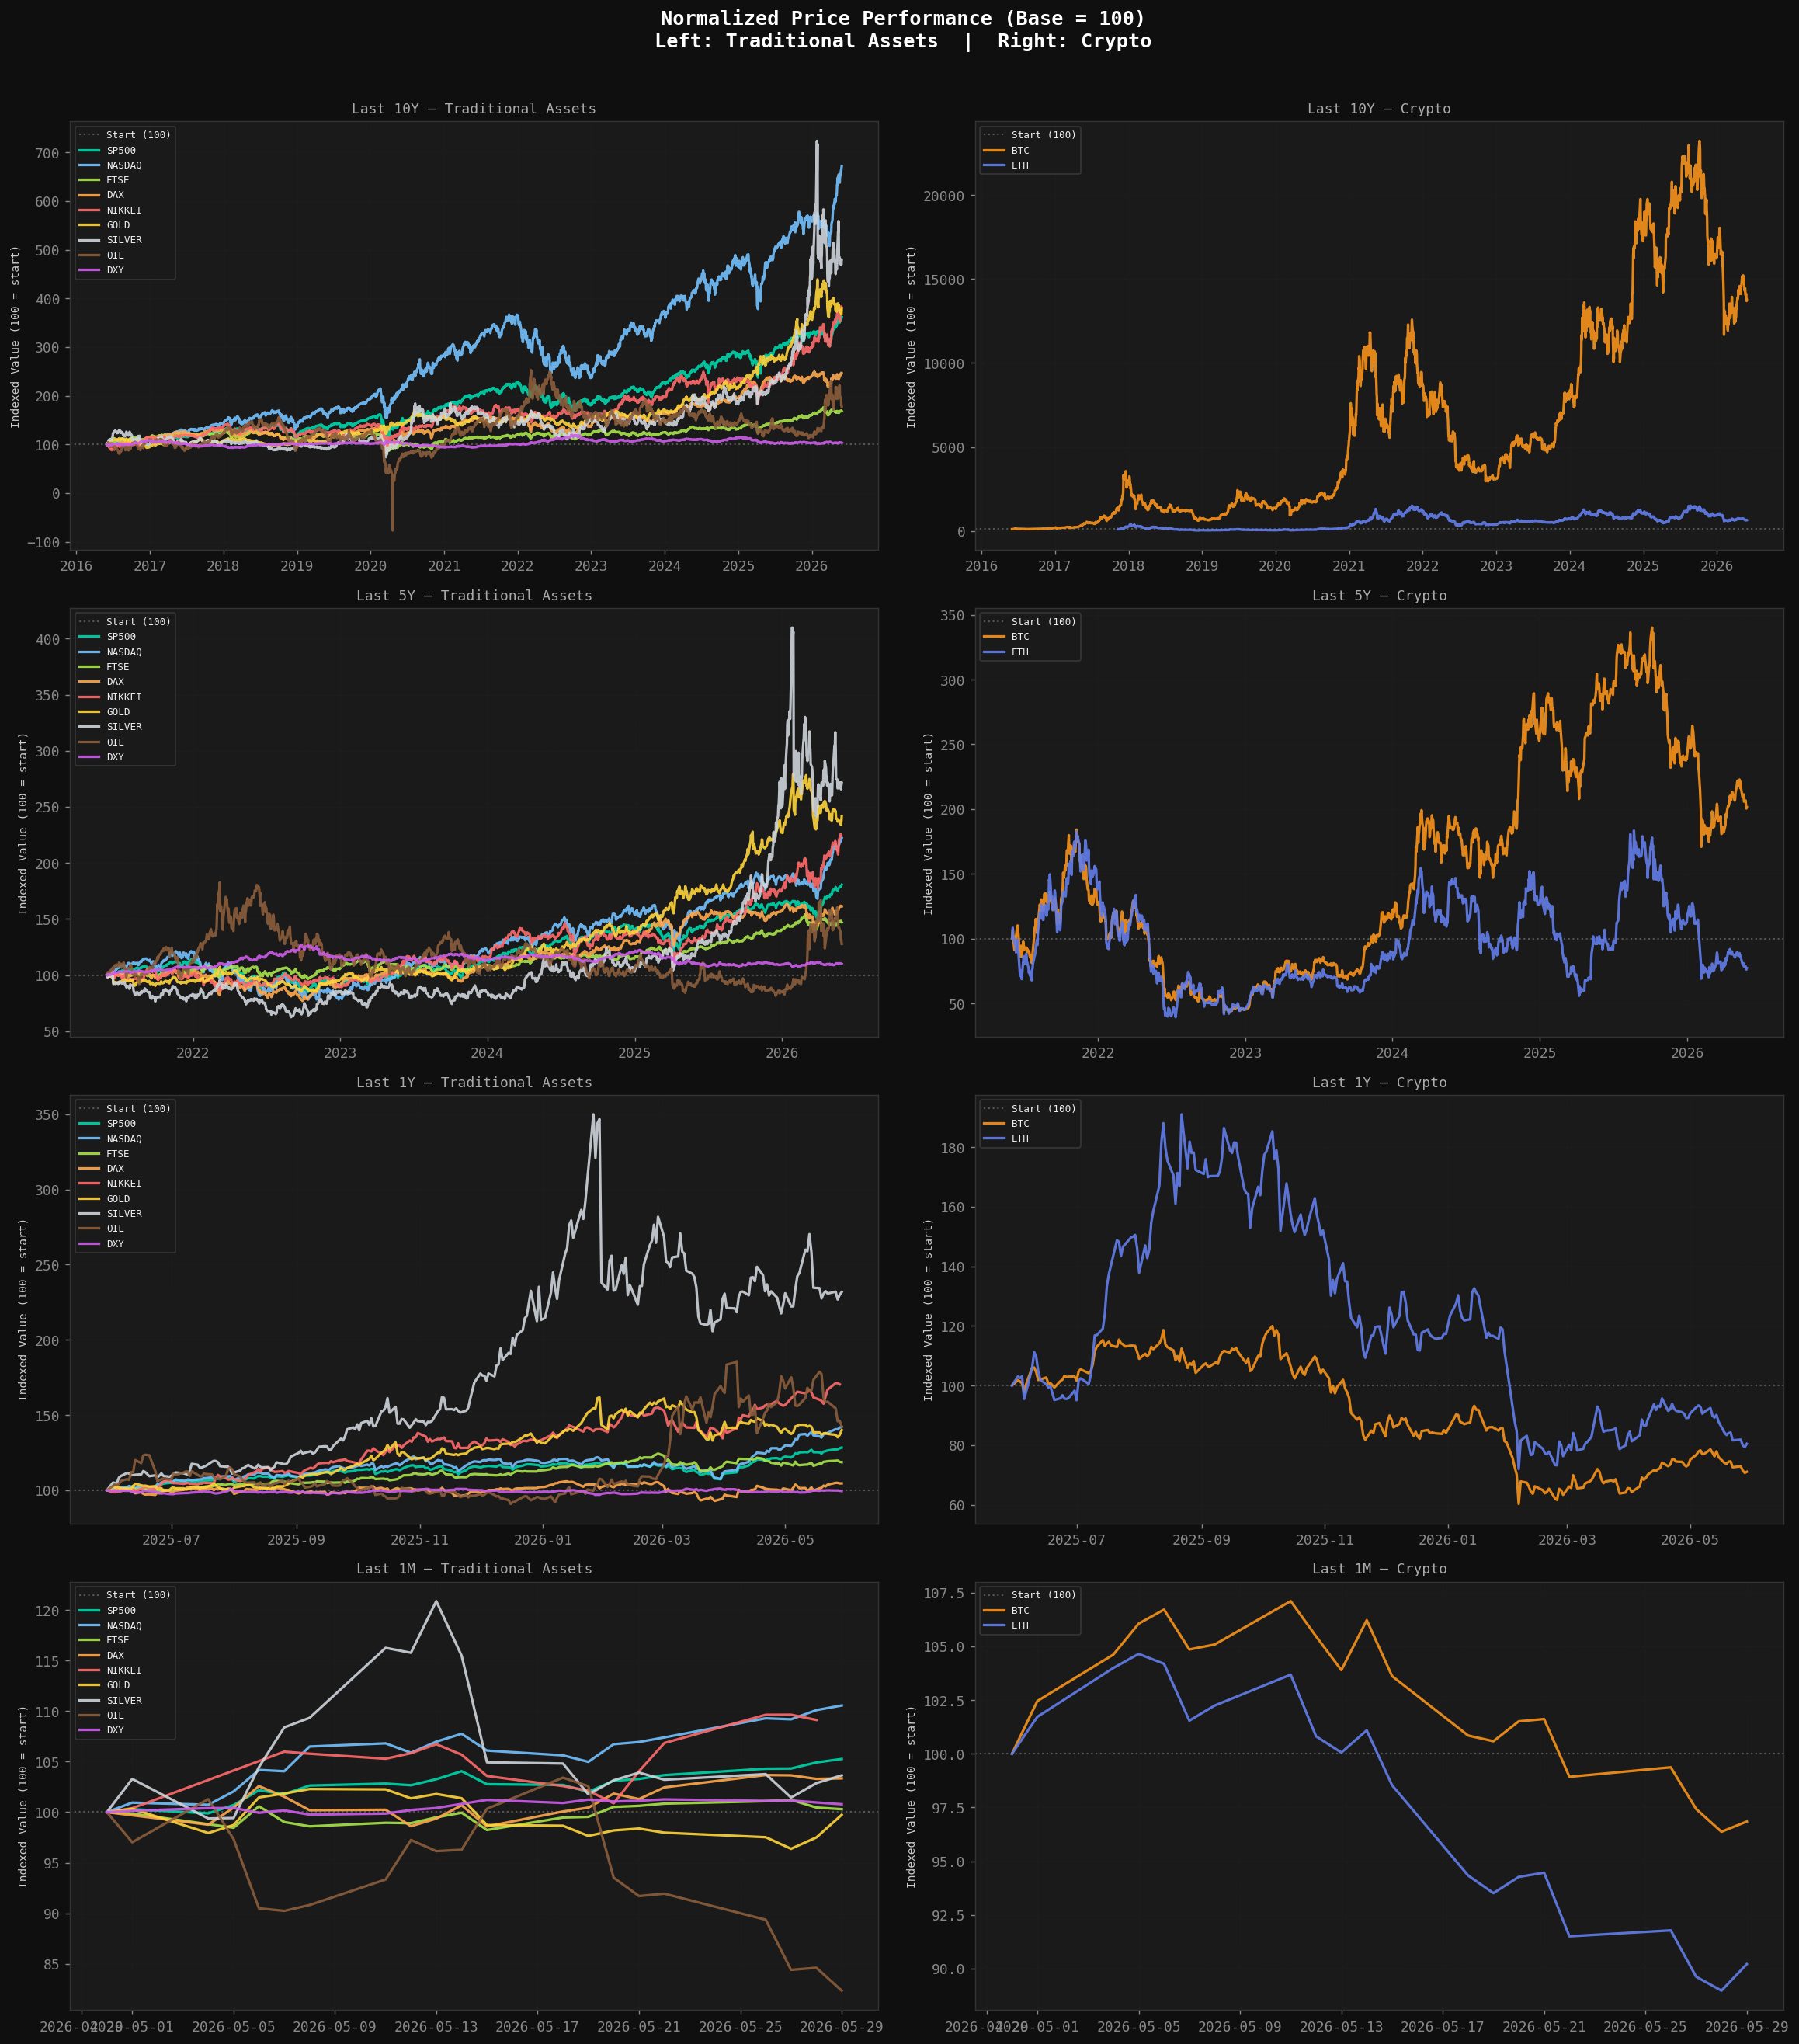

💾 Saved: normalized_performance.png

💡 Assets above 100 gained value, below 100 lost value.
   Crypto is shown separately due to extreme scale differences.


In [23]:
# ─────────────────────────────────────────────────────────────────
# CHART 1: NORMALIZED PRICE HISTORY
#
# All assets start at 100 on day 1 of each period
# This allows fair comparison regardless of actual price levels
#
# Formula: normalized = (price / first_price) × 100
# 100 = starting point
# 200 = doubled (+100%)
# 50  = halved  (-50%)
#
# We split assets into two groups for readability:
# Group 1: Traditional assets (indices + commodities)
# Group 2: Crypto assets (BTC + ETH) — much higher volatility
# ─────────────────────────────────────────────────────────────────

GROUP1 = ['SP500', 'NASDAQ', 'FTSE', 'DAX', 'NIKKEI', 'GOLD', 'SILVER', 'OIL', 'DXY']
GROUP2 = ['BTC', 'ETH']

fig, axes = plt.subplots(4, 2, figsize=(18, 20))
fig.suptitle(
    'Normalized Price Performance (Base = 100)\nLeft: Traditional Assets  |  Right: Crypto',
    fontsize=14, fontweight='bold', color='white', y=1.01
)

for row, period in enumerate(['10Y', '5Y', '1Y', '1M']):
    start = PERIODS[period]

    for col, (group, title) in enumerate([
        (GROUP1, 'Traditional Assets'),
        (GROUP2, 'Crypto')
    ]):
        ax = axes[row, col]

        # Reference line: 100 = starting point
        ax.axhline(y=100, color='#555555', linestyle=':',
                   linewidth=1.2, label='Start (100)')

        for asset in group:
            if asset not in price_df.columns:
                continue

            series = price_df[asset][price_df.index >= start].dropna()
            if len(series) < 2:
                continue

            # Normalize: divide by first value, multiply by 100
            normalized = (series / series.iloc[0]) * 100
            color = PALETTE.get(asset, '#888888')

            ax.plot(
                normalized.index,
                normalized.values,
                label=asset,
                color=color,
                linewidth=1.8,
                alpha=0.9
            )

        ax.set_title(
            f'Last {period} — {title}',
            color='#aaaaaa', fontsize=10, pad=6
        )
        ax.set_ylabel('Indexed Value (100 = start)', fontsize=8)
        ax.legend(loc='upper left', fontsize=7, framealpha=0.15)
        ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(
    'normalized_performance.png',
    dpi=150, bbox_inches='tight', facecolor='#0f0f0f'
)
plt.show()
print("💾 Saved: normalized_performance.png")
print("\n💡 Assets above 100 gained value, below 100 lost value.")
print("   Crypto is shown separately due to extreme scale differences.")

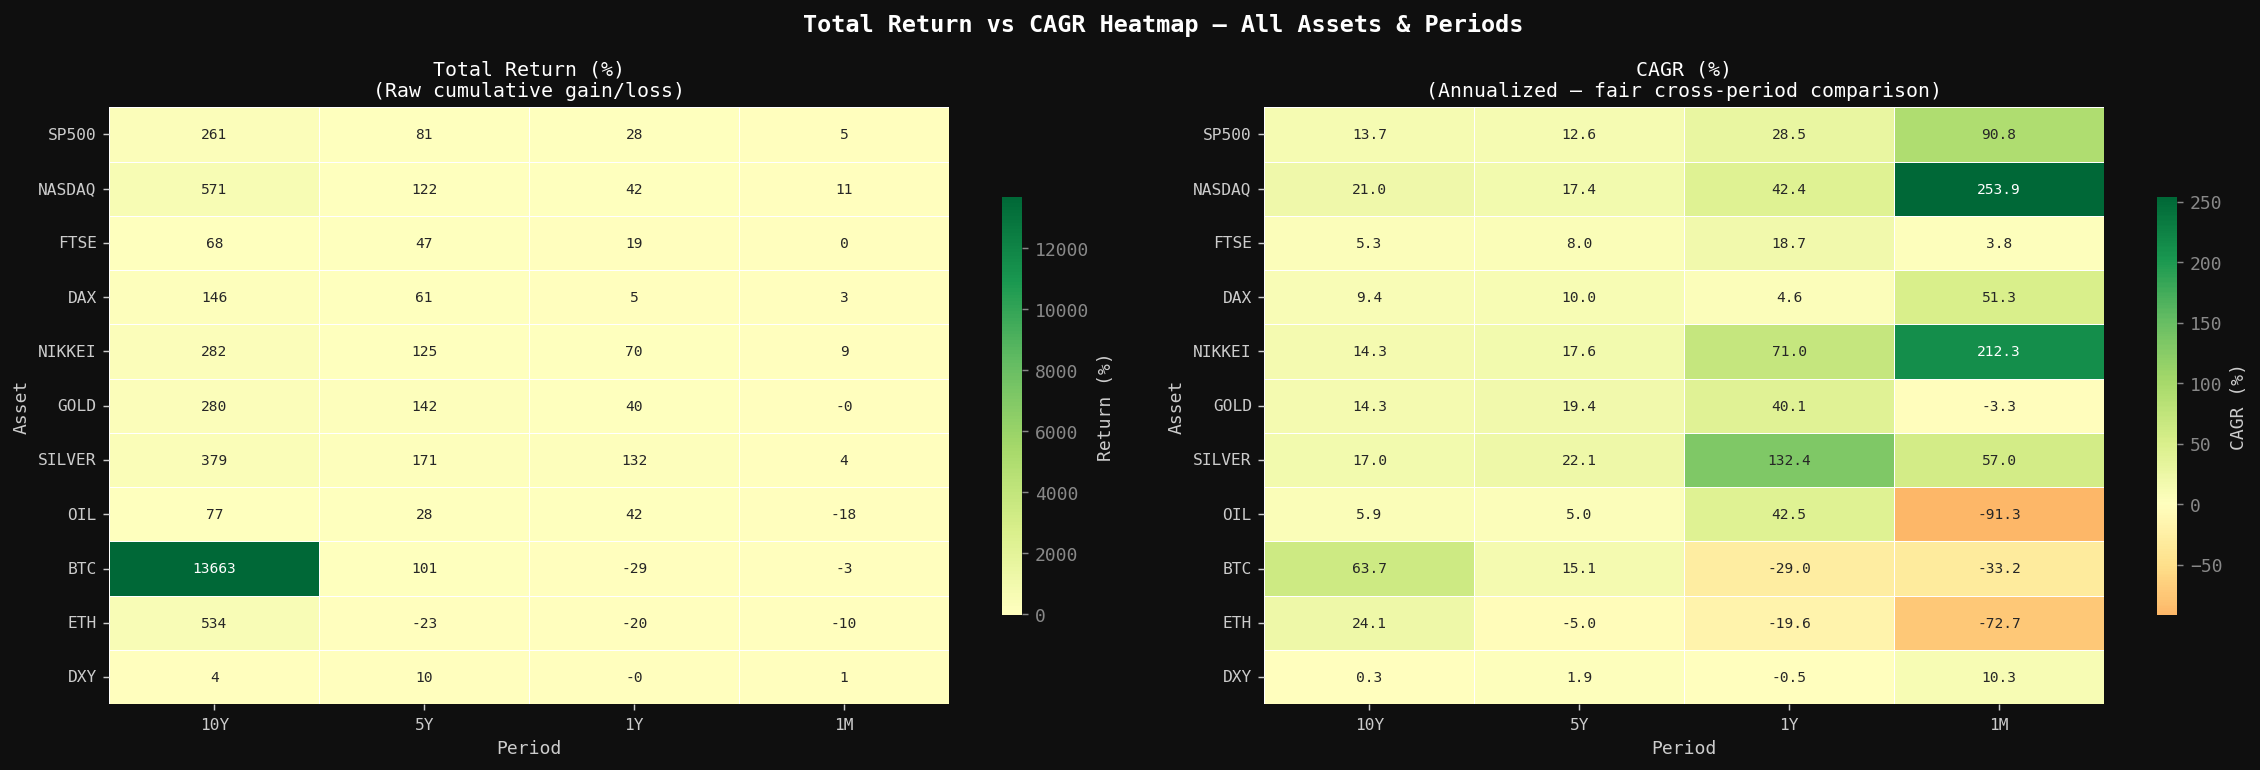

💾 Saved: return_heatmap.png

💡 CAGR is more meaningful than Total Return for comparing
   assets across different time horizons.
   Example: 100% in 1Y vs 100% in 10Y are very different outcomes.


In [24]:
# ─────────────────────────────────────────────────────────────────
# CHART 2: TOTAL RETURN HEATMAP
#
# Color-coded table — spot winners and losers instantly
# Green = positive/high return
# Red   = negative/low return
#
# Two heatmaps side by side:
# Left  → Total Return (%) — raw numbers
# Right → CAGR (%) — annualized, makes periods comparable
#
# .T → transpose the DataFrame
# Rows = assets, Columns = periods
# This orientation is easier to read
# ─────────────────────────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(
    'Total Return vs CAGR Heatmap — All Assets & Periods',
    fontsize=13, fontweight='bold', color='white'
)

# ── Left: Total Return ───────────────────────────────────────────
sns.heatmap(
    return_df.T,           # transpose: assets as rows
    annot=True,            # show numbers in each cell
    fmt='.0f',             # no decimals
    cmap='RdYlGn',         # red → yellow → green
    center=0,              # 0 = yellow (neutral)
    linewidths=0.5,
    ax=ax1,
    annot_kws={'size': 8},
    cbar_kws={'shrink': 0.7, 'label': 'Return (%)'}
)
ax1.set_title('Total Return (%)\n(Raw cumulative gain/loss)',
              color='white', fontsize=11)
ax1.tick_params(colors='#cccccc', labelsize=9)
ax1.set_xlabel('Period', color='#cccccc')
ax1.set_ylabel('Asset', color='#cccccc')

# ── Right: CAGR ──────────────────────────────────────────────────
sns.heatmap(
    cagr_df.T,
    annot=True,
    fmt='.1f',             # 1 decimal for CAGR
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    ax=ax2,
    annot_kws={'size': 8},
    cbar_kws={'shrink': 0.7, 'label': 'CAGR (%)'}
)
ax2.set_title('CAGR (%)\n(Annualized — fair cross-period comparison)',
              color='white', fontsize=11)
ax2.tick_params(colors='#cccccc', labelsize=9)
ax2.set_xlabel('Period', color='#cccccc')
ax2.set_ylabel('Asset', color='#cccccc')

plt.tight_layout()
plt.savefig(
    'return_heatmap.png',
    dpi=150, bbox_inches='tight', facecolor='#0f0f0f'
)
plt.show()
print("💾 Saved: return_heatmap.png")
print("\n💡 CAGR is more meaningful than Total Return for comparing")
print("   assets across different time horizons.")
print("   Example: 100% in 1Y vs 100% in 10Y are very different outcomes.")

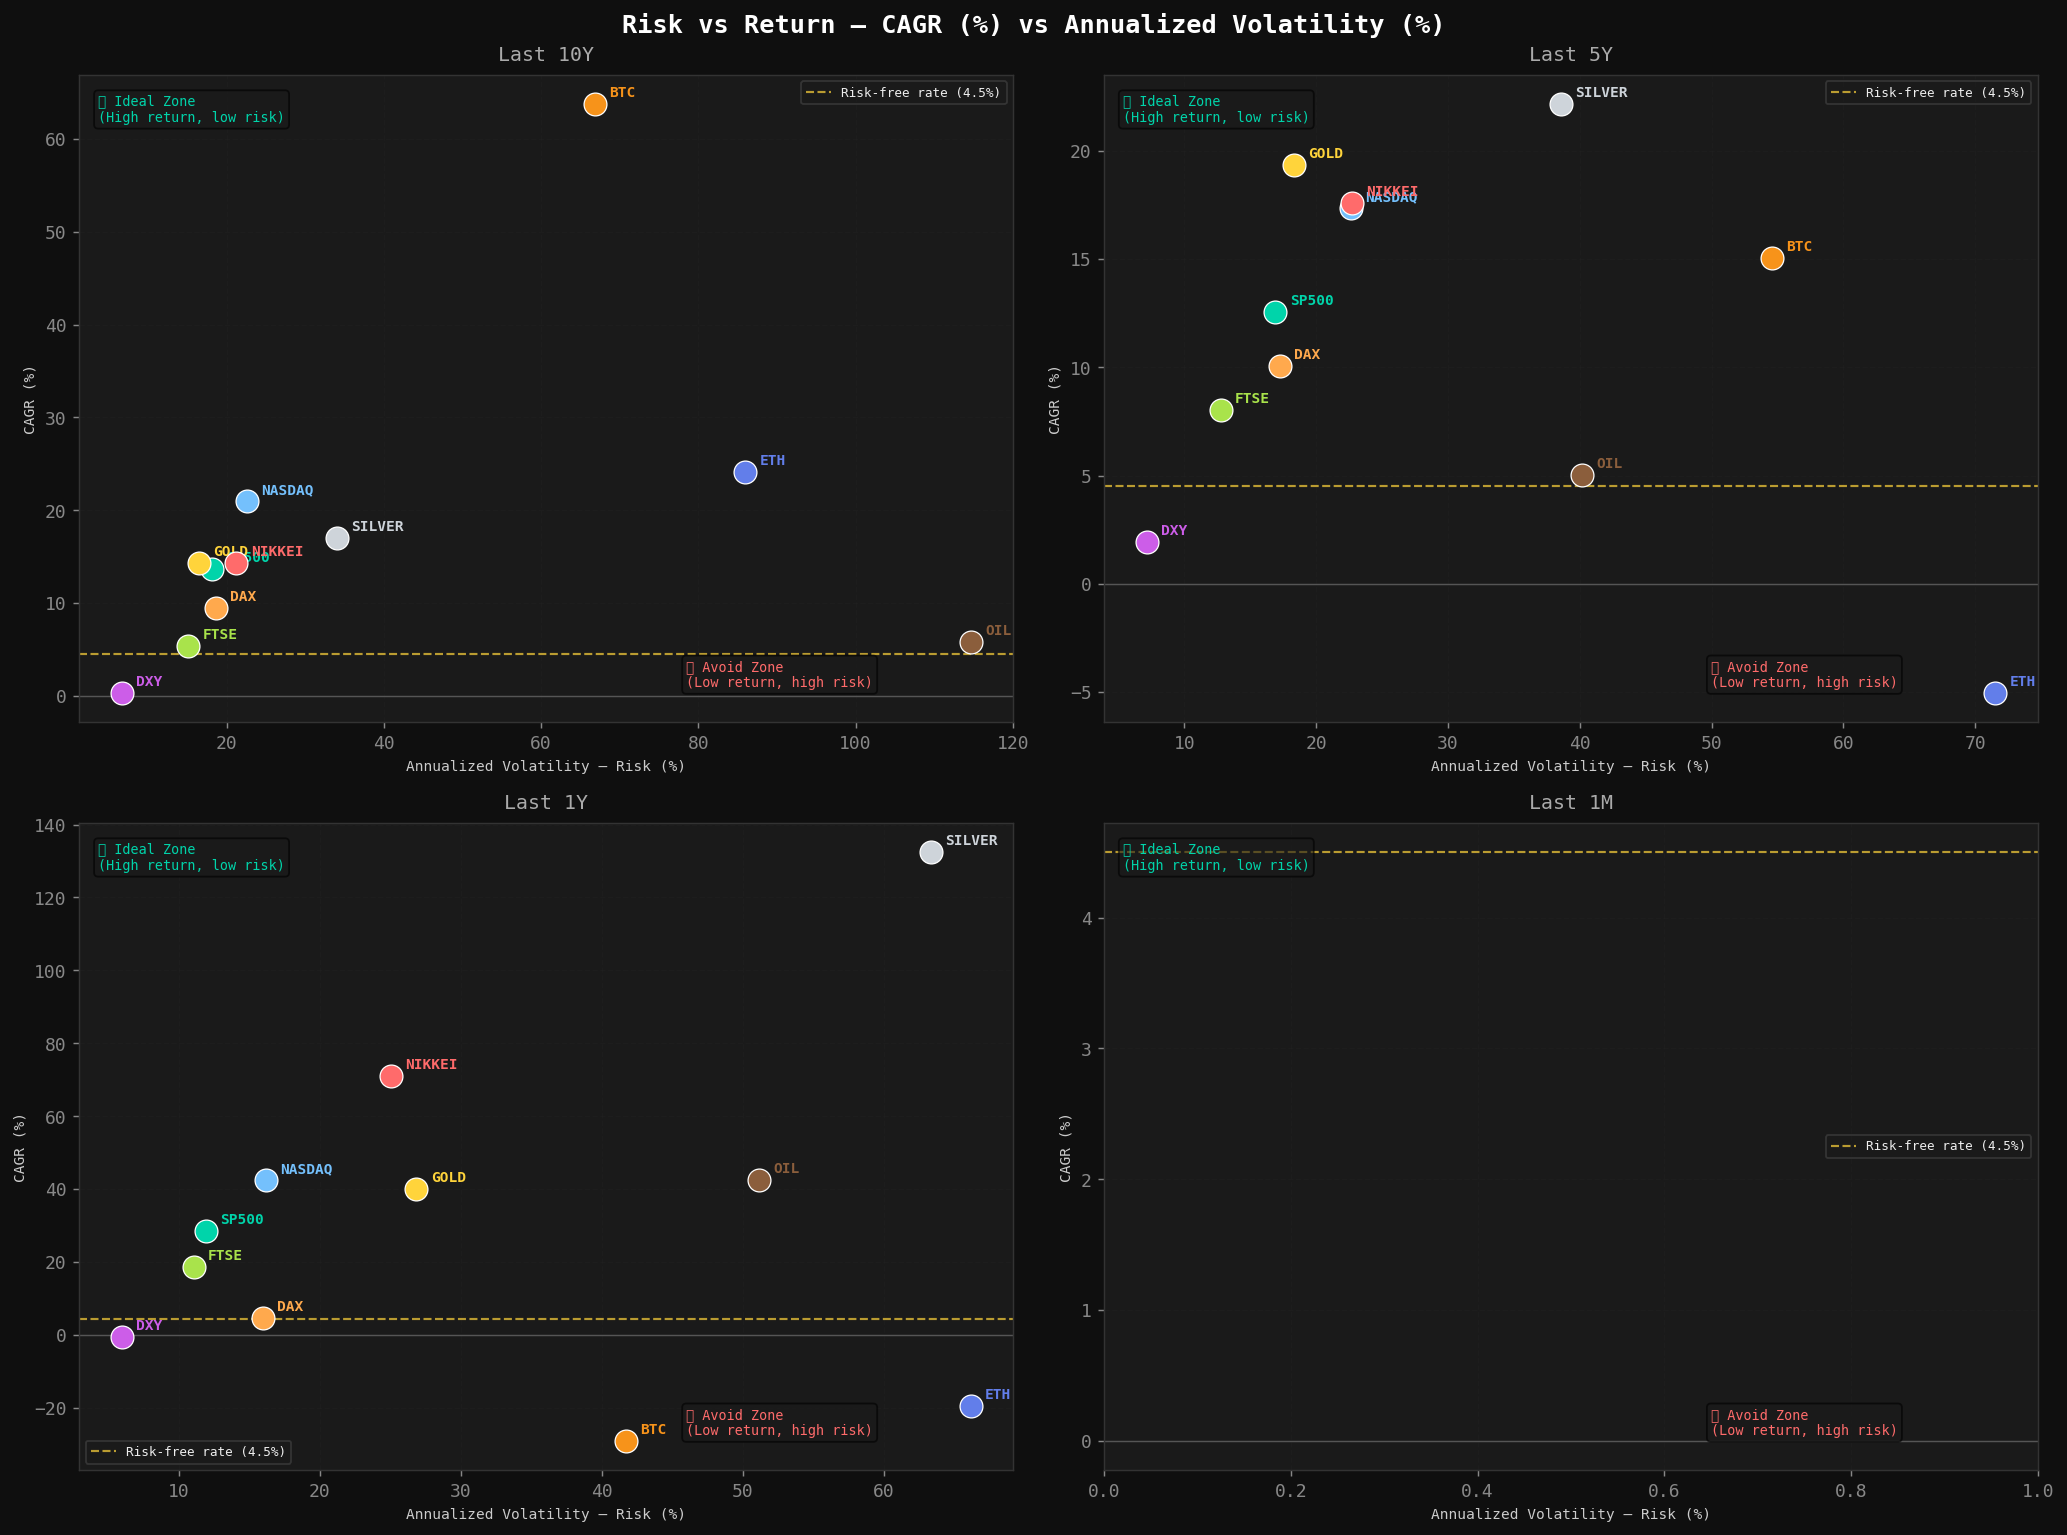

💾 Saved: risk_return_scatter.png

💡 Assets in the top-left quadrant offer the best risk/return tradeoff.
   The yellow dashed line = US Treasury yield (risk-free benchmark).
   Assets below this line didn't beat a simple savings account.


In [25]:
# ─────────────────────────────────────────────────────────────────
# CHART 3: RISK vs RETURN SCATTER PLOT
#
# Each asset = one dot on the chart
# X axis = Risk (annualized volatility %)
# Y axis = CAGR (%) — annualized return
#
# IDEAL position: TOP-LEFT
# → High return, low risk
#
# AVOID position: BOTTOM-RIGHT
# → Low return, high risk
#
# We plot all 4 periods in one figure (2×2 grid)
# Each period tells a different story
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    'Risk vs Return — CAGR (%) vs Annualized Volatility (%)',
    fontsize=14, fontweight='bold', color='white'
)

for ax, period in zip(axes.flatten(), ['10Y', '5Y', '1Y', '1M']):
    start = PERIODS[period]

    # Get CAGR and Volatility for this period
    cagr_period = cagr_df.loc[period].dropna()
    vol_period  = vol_df.loc[period].dropna()

    # Only plot assets that have both metrics
    common = cagr_period.index.intersection(vol_period.index)

    for asset in common:
        x     = vol_period[asset]    # risk (x axis)
        y     = cagr_period[asset]   # return (y axis)
        color = PALETTE.get(asset, '#888888')

        # Draw the dot
        ax.scatter(
            x, y,
            color=color,
            s=160,
            zorder=5,
            edgecolors='white',
            linewidth=0.7
        )

        # Label the dot with asset name
        ax.annotate(
            asset, (x, y),
            textcoords='offset points',
            xytext=(8, 4),
            fontsize=8,
            color=color,
            fontweight='bold'
        )

    # Zero return line
    ax.axhline(0, color='#555555', linewidth=0.8)

    # Risk-free rate reference line (4.5% = US Treasury)
    ax.axhline(
        4.5,
        color='#ffd43b',
        linestyle='--',
        linewidth=1.2,
        alpha=0.7,
        label='Risk-free rate (4.5%)'
    )

    # Region labels
    ax.text(
        0.02, 0.97,
        '✅ Ideal Zone\n(High return, low risk)',
        transform=ax.transAxes,
        fontsize=7.5, color='#00d4aa',
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='#1a1a1a', alpha=0.6)
    )
    ax.text(
        0.65, 0.05,
        '❌ Avoid Zone\n(Low return, high risk)',
        transform=ax.transAxes,
        fontsize=7.5, color='#ff6b6b',
        verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='#1a1a1a', alpha=0.6)
    )

    ax.set_title(f'Last {period}', color='#aaaaaa', fontsize=11, pad=8)
    ax.set_xlabel('Annualized Volatility — Risk (%)', fontsize=8)
    ax.set_ylabel('CAGR (%)', fontsize=8)
    ax.legend(fontsize=7, framealpha=0.15)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(
    'risk_return_scatter.png',
    dpi=150, bbox_inches='tight', facecolor='#0f0f0f'
)
plt.show()
print("💾 Saved: risk_return_scatter.png")
print("\n💡 Assets in the top-left quadrant offer the best risk/return tradeoff.")
print("   The yellow dashed line = US Treasury yield (risk-free benchmark).")
print("   Assets below this line didn't beat a simple savings account.")

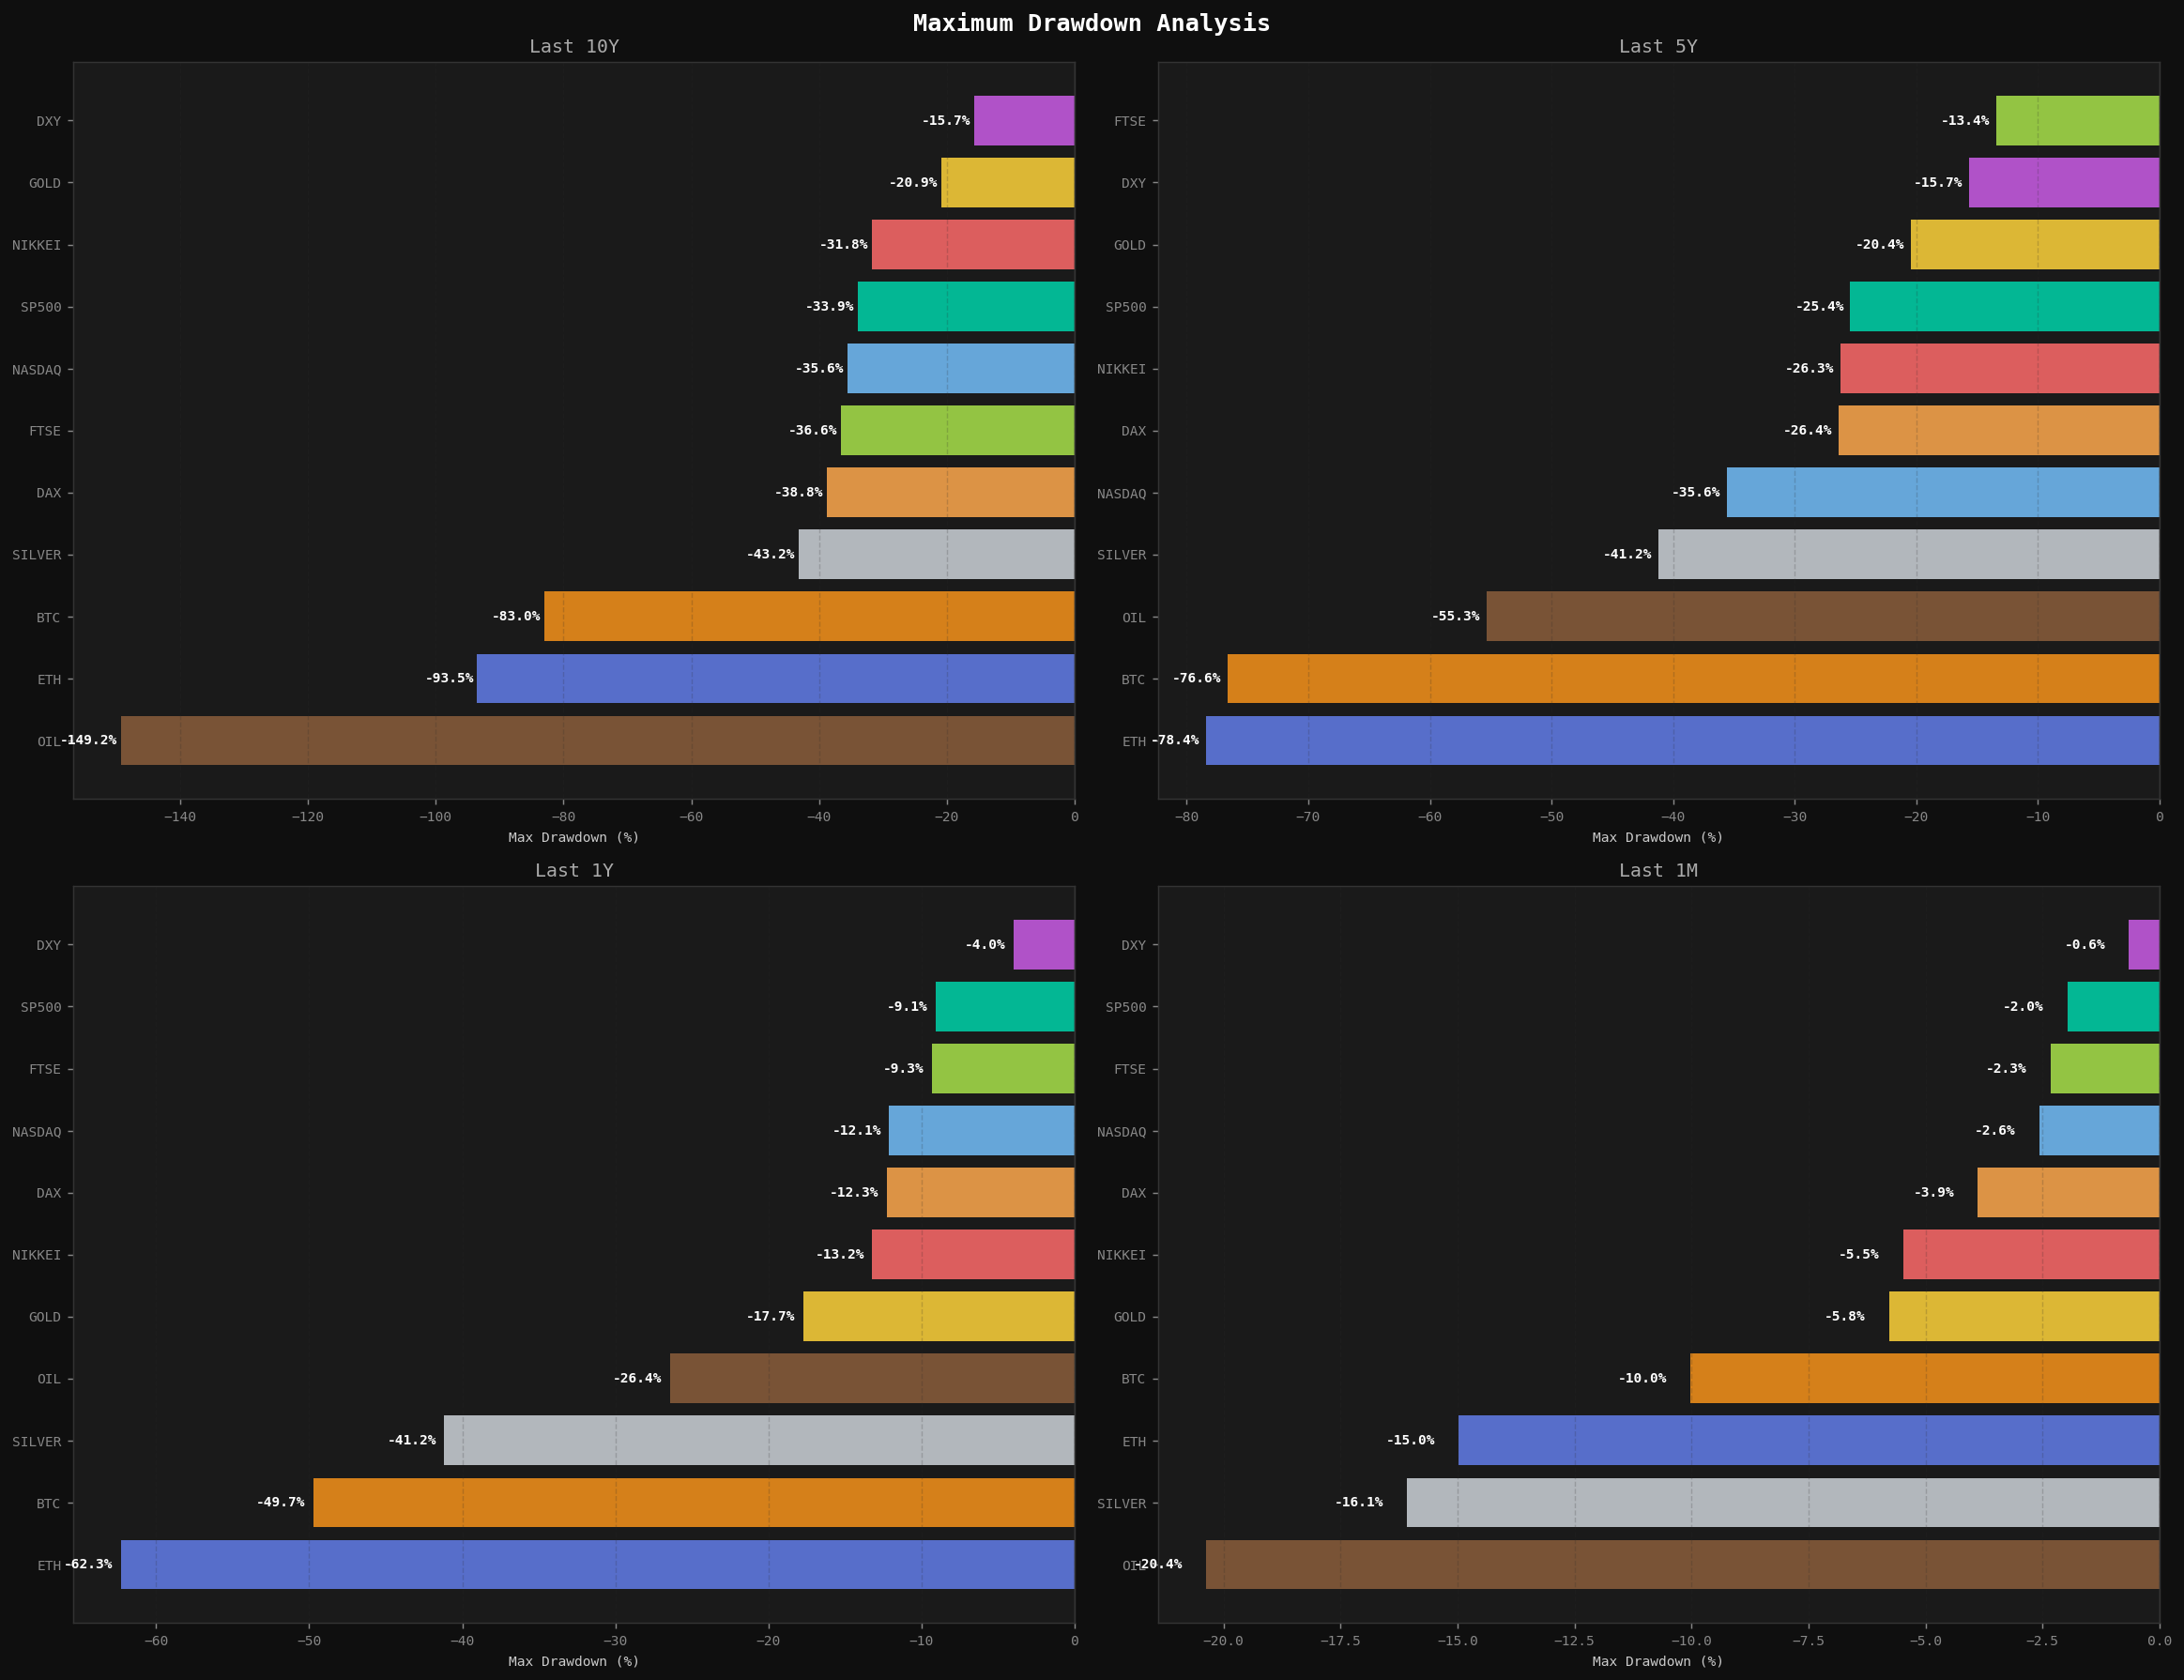

💾 Saved: max_drawdown.png


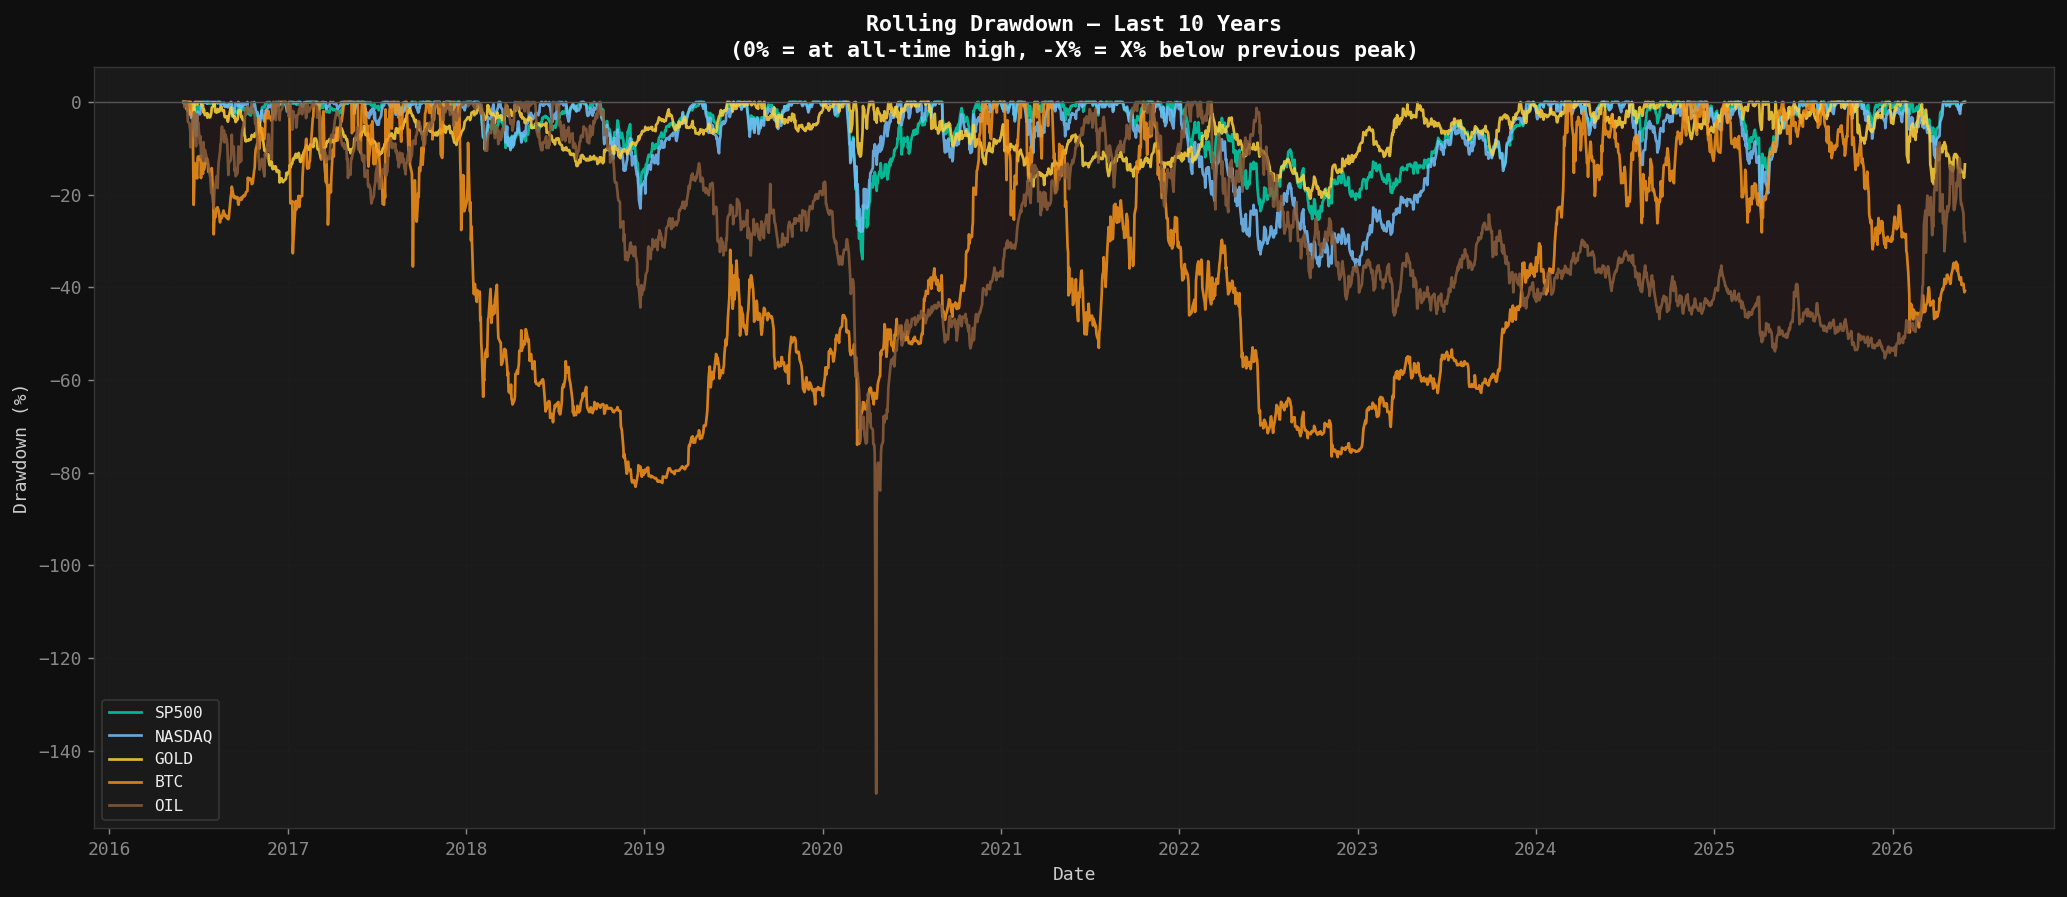

💾 Saved: rolling_drawdown.png

💡 The deeper the line goes, the worse the loss from peak.
   COVID crash (Mar 2020) and rate hike period (2022) are clearly visible.


In [26]:
# ─────────────────────────────────────────────────────────────────
# CHART 4: MAXIMUM DRAWDOWN
#
# Max Drawdown answers: "How much could I have lost at worst?"
# Always negative — shows the deepest decline from peak to trough
#
# Two visualizations:
# Top → Bar chart: max drawdown per asset per period
# Bottom → Line chart: rolling drawdown over time (10Y)
#          Shows WHEN the worst drawdowns happened
#
# Rolling drawdown:
# At each day: how far are we from the previous all-time high?
# 0% = at all-time high
# -50% = price is half of its previous peak
# ─────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Maximum Drawdown Analysis', 
             fontsize=14, fontweight='bold', color='white')

# ── Top: Max Drawdown Bar Chart (all periods) ────────────────────
axes_top = [fig.add_subplot(2, 2, i+1) for i in range(4)]

for ax, period in zip(axes_top, ['10Y', '5Y', '1Y', '1M']):
    dd_period = drawdown_df.loc[period].dropna().sort_values()

    colors = [PALETTE.get(a, '#888888') for a in dd_period.index]

    bars = ax.barh(
        dd_period.index,
        dd_period.values,
        color=colors,
        edgecolor='none',
        alpha=0.85
    )

    # Add value labels
    for bar, val in zip(bars, dd_period.values):
        ax.text(
            val - 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%',
            ha='right', va='center',
            fontsize=8, color='white', fontweight='bold'
        )

    ax.axvline(0, color='#444444', linewidth=0.8)
    ax.set_title(f'Last {period}', color='#aaaaaa', fontsize=11)
    ax.set_xlabel('Max Drawdown (%)', fontsize=8)
    ax.grid(axis='x', alpha=0.2)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(
    'max_drawdown.png',
    dpi=150, bbox_inches='tight', facecolor='#0f0f0f'
)
plt.show()
print("💾 Saved: max_drawdown.png")

# ── Rolling Drawdown Chart (10Y) ─────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(16, 7))
ax2.set_title(
    'Rolling Drawdown — Last 10 Years\n'
    '(0% = at all-time high, -X% = X% below previous peak)',
    fontsize=12, fontweight='bold', color='white'
)

plot_assets = ['SP500', 'NASDAQ', 'GOLD', 'BTC', 'OIL']

for asset in plot_assets:
    if asset not in price_df.columns:
        continue

    series      = price_df[asset][price_df.index >= PERIODS['10Y']].dropna()
    rolling_max = series.cummax()
    drawdown    = (series - rolling_max) / rolling_max * 100
    color       = PALETTE.get(asset, '#888888')

    ax2.plot(
        drawdown.index,
        drawdown.values,
        label=asset,
        color=color,
        linewidth=1.5,
        alpha=0.85
    )

ax2.axhline(0, color='#555555', linewidth=0.8)
ax2.fill_between(
    drawdown.index,
    drawdown.values,
    0,
    alpha=0.03,
    color='red'
)

ax2.set_ylabel('Drawdown (%)', fontsize=10)
ax2.set_xlabel('Date', fontsize=10)
ax2.legend(fontsize=9, framealpha=0.15)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(
    'rolling_drawdown.png',
    dpi=150, bbox_inches='tight', facecolor='#0f0f0f'
)
plt.show()
print("💾 Saved: rolling_drawdown.png")
print("\n💡 The deeper the line goes, the worse the loss from peak.")
print("   COVID crash (Mar 2020) and rate hike period (2022) are clearly visible.")

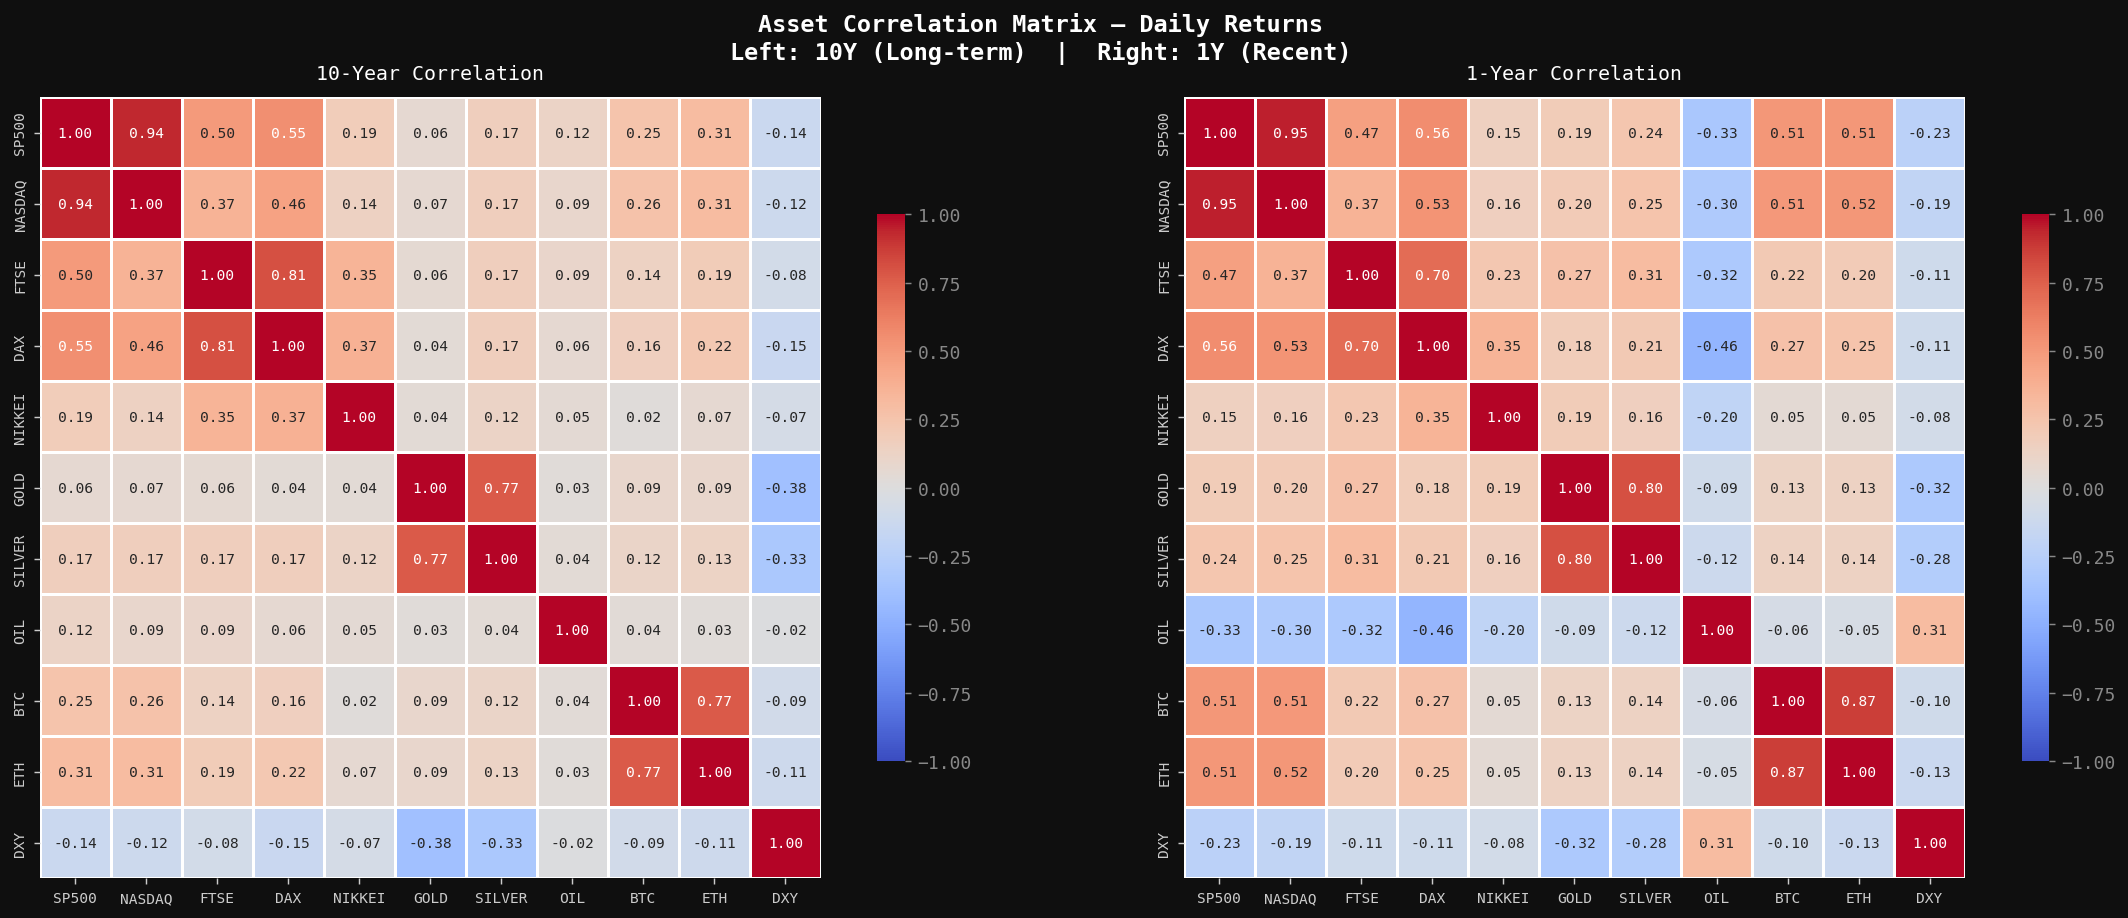

💾 Saved: correlation_matrix.png

📌 CORRELATION INSIGHTS (10Y):
-------------------------------------------------------

   Most correlated (move together — less diversification):
   SP500    ↔ NASDAQ  : +0.94
   FTSE     ↔ DAX     : +0.81
   GOLD     ↔ SILVER  : +0.77

   Least correlated (more diversification benefit):
   DAX      ↔ DXY     : -0.15
   SILVER   ↔ DXY     : -0.33
   GOLD     ↔ DXY     : -0.38


In [27]:
# ─────────────────────────────────────────────────────────────────
# CHART 5: CORRELATION MATRIX
#
# Correlation measures how assets move together:
# +1.0 → perfect positive (rise and fall together)
#  0.0 → no correlation (independent movement)
# -1.0 → perfect negative (one rises when other falls)
#
# WHY IT MATTERS FOR PORTFOLIOS:
# Holding highly correlated assets = no real diversification
# You want LOW correlation between assets in your portfolio
# When one falls, the other shouldn't fall too
#
# We calculate correlation on DAILY RETURNS (not prices)
# Price correlation is misleading — both could trend up long-term
# Return correlation shows actual day-to-day relationship
#
# We show TWO matrices:
# Left  → 10Y correlation (long-term relationship)
# Right → 1Y correlation (recent relationship — may differ!)
# ─────────────────────────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'Asset Correlation Matrix — Daily Returns\n'
    'Left: 10Y (Long-term)  |  Right: 1Y (Recent)',
    fontsize=13, fontweight='bold', color='white'
)

for ax, period, title in [
    (ax1, '10Y', '10-Year Correlation'),
    (ax2, '1Y',  '1-Year Correlation')
]:
    start = PERIODS[period]

    # Filter data for this period
    data_period = price_df[price_df.index >= start].dropna(how='all')

    # Daily returns
    daily_returns = data_period.pct_change().dropna(how='all')

    # Correlation matrix
    corr = daily_returns.corr()

    sns.heatmap(
        corr,
        annot=True,          # show correlation values
        fmt='.2f',           # 2 decimal places
        cmap='coolwarm',     # blue (negative) → white (0) → red (positive)
        center=0,
        vmin=-1, vmax=1,     # fixed scale -1 to +1
        square=True,         # square cells
        linewidths=0.8,
        ax=ax,
        annot_kws={'size': 8},
        cbar_kws={'shrink': 0.7}
    )

    ax.set_title(title, color='white', fontsize=11, pad=10)
    ax.tick_params(colors='#cccccc', labelsize=8)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig(
    'correlation_matrix.png',
    dpi=150, bbox_inches='tight', facecolor='#0f0f0f'
)
plt.show()
print("💾 Saved: correlation_matrix.png")

# ─────────────────────────────────────────────────────────────────
# CORRELATION INSIGHTS
# ─────────────────────────────────────────────────────────────────

print("\n📌 CORRELATION INSIGHTS (10Y):")
print("-" * 55)

# Calculate 10Y correlation
data_10y  = price_df[price_df.index >= PERIODS['10Y']].dropna(how='all')
corr_10y  = data_10y.pct_change().dropna(how='all').corr()

# Find highest and lowest correlation pairs
pairs = []
cols  = corr_10y.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        val = corr_10y.loc[cols[i], cols[j]]
        if not pd.isna(val):
            pairs.append((cols[i], cols[j], val))

pairs.sort(key=lambda x: x[2], reverse=True)

print("\n   Most correlated (move together — less diversification):")
for a1, a2, val in pairs[:3]:
    print(f"   {a1:8s} ↔ {a2:8s}: {val:+.2f}")

print("\n   Least correlated (more diversification benefit):")
for a1, a2, val in pairs[-3:]:
    print(f"   {a1:8s} ↔ {a2:8s}: {val:+.2f}")

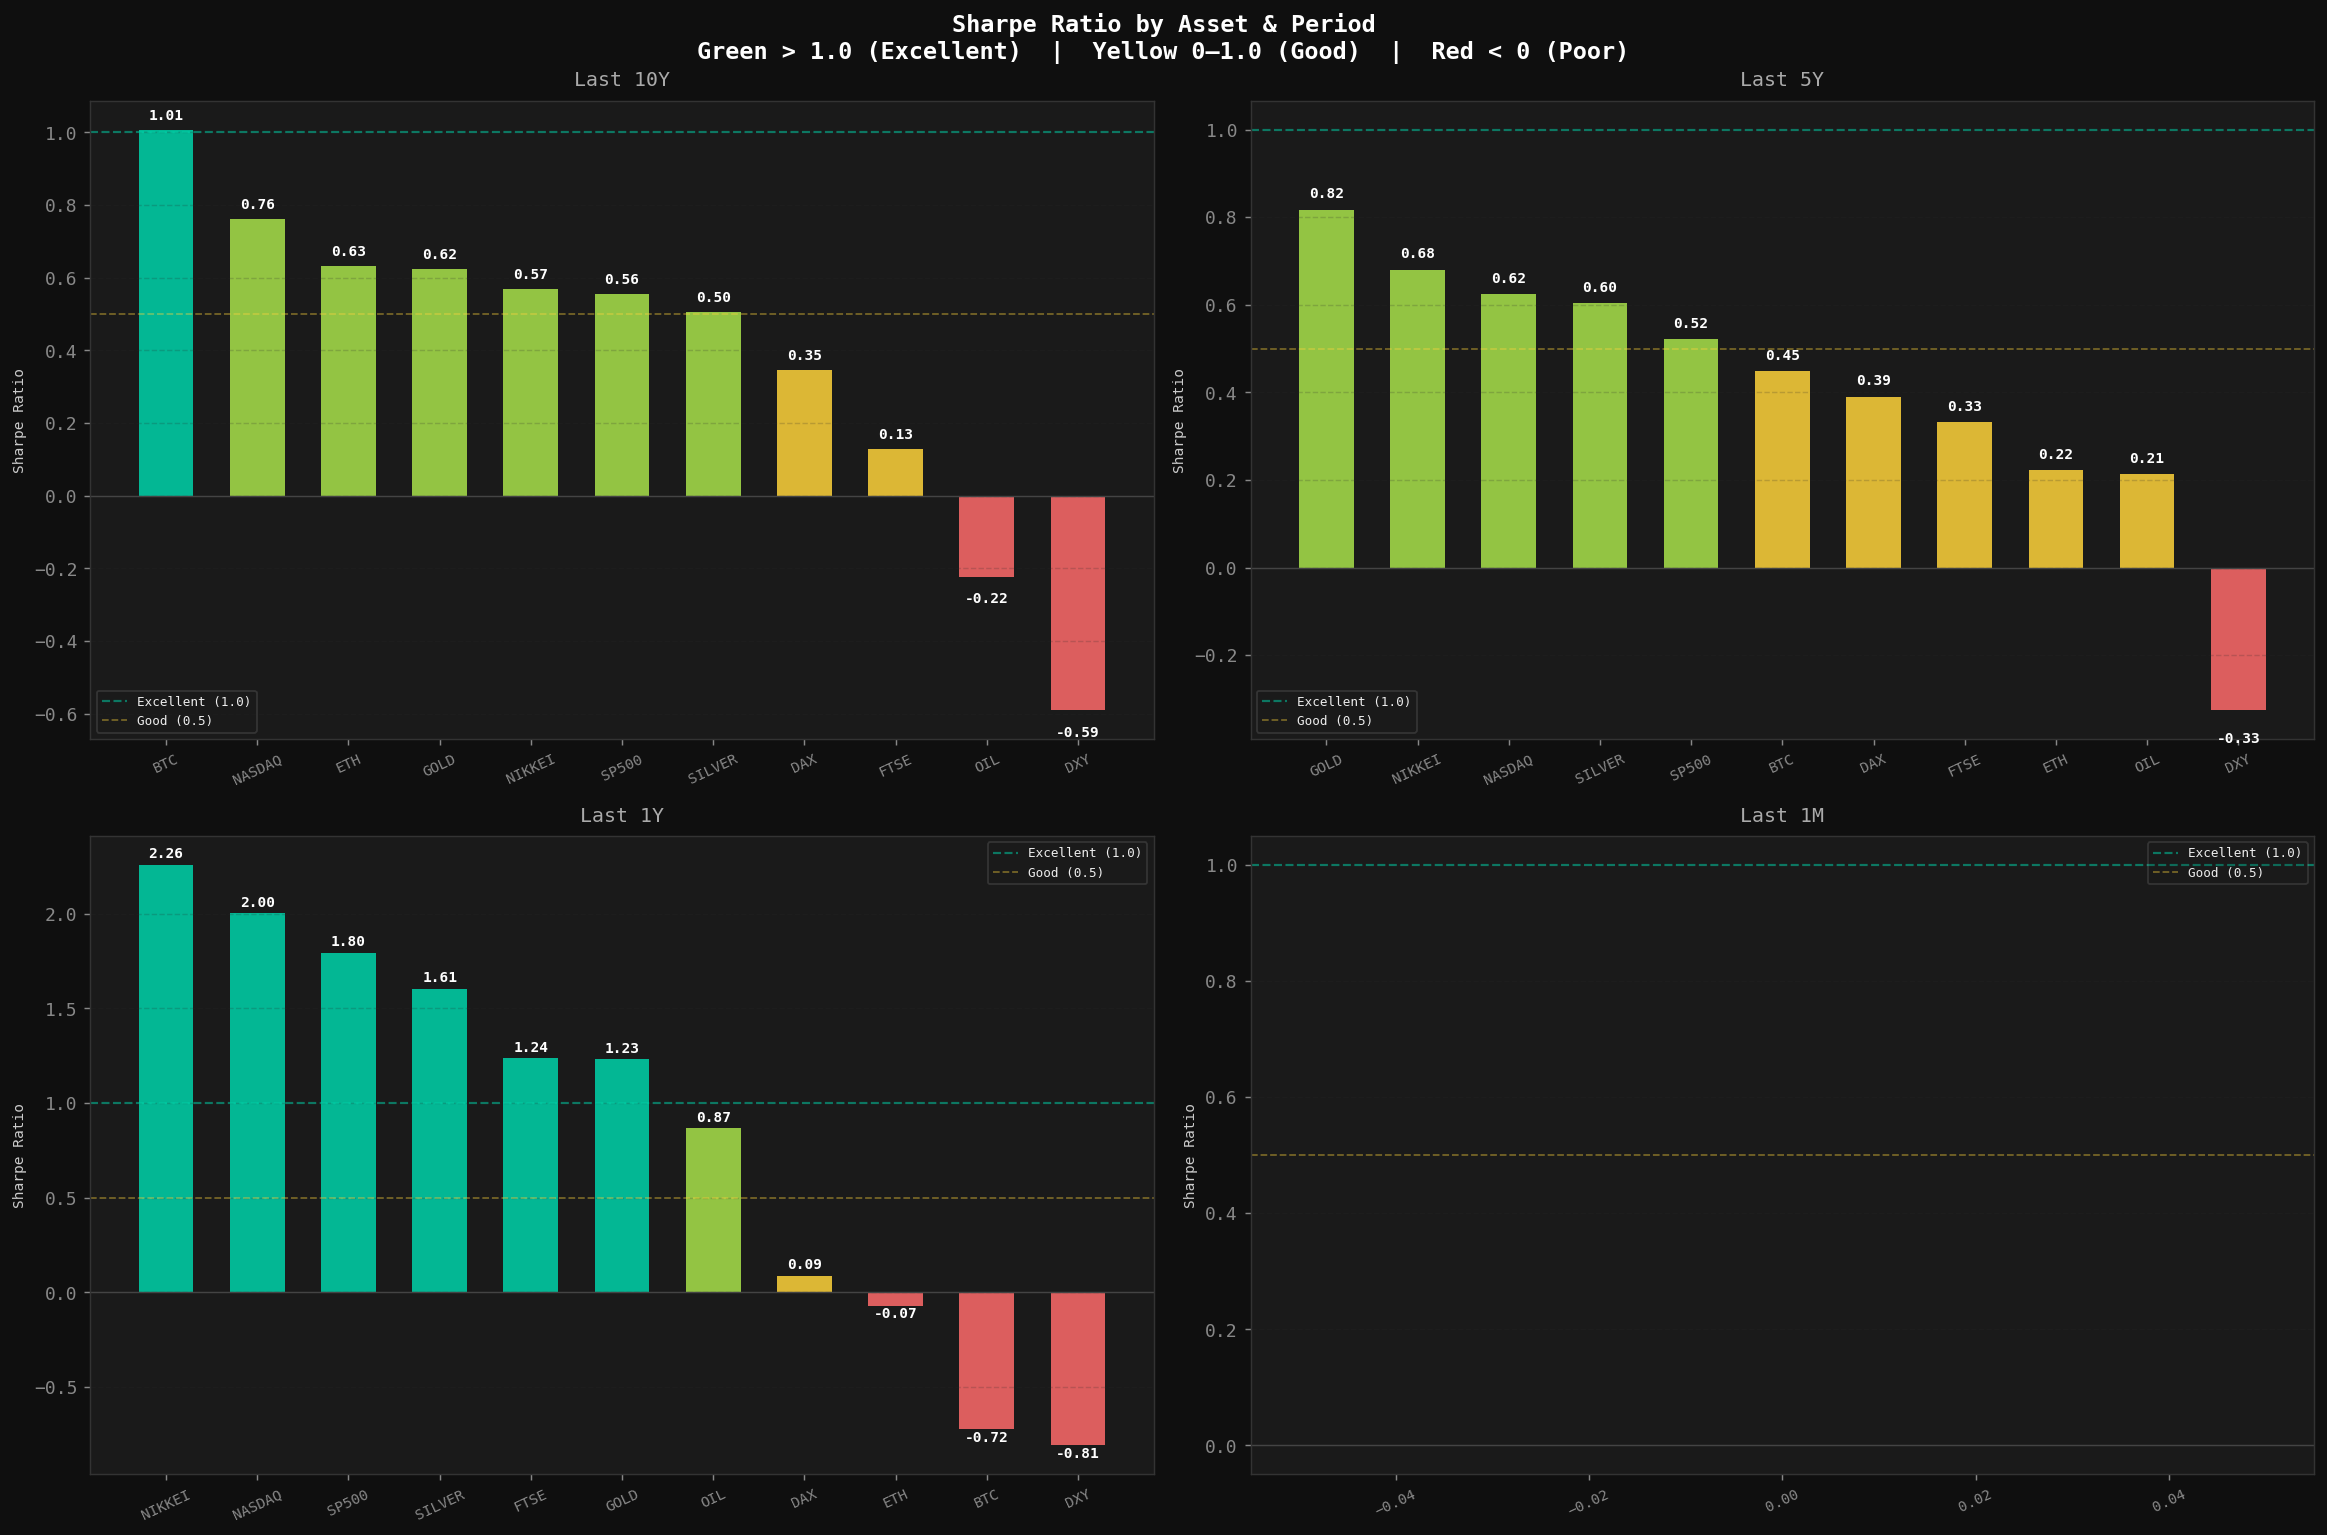

💾 Saved: sharpe_comparison.png

💡 Sharpe > 1.0 means excellent risk-adjusted performance.
   An asset with high return but very high volatility
   may have a LOWER Sharpe than a steadier, lower-return asset.


In [28]:
# ─────────────────────────────────────────────────────────────────
# CHART 6: SHARPE RATIO COMPARISON
#
# Sharpe Ratio = return per unit of risk
# The most important metric for comparing investments
#
# Bar chart: each asset's Sharpe across all periods
# Color coding:
#   Green  → Sharpe > 1.0 (excellent)
#   Yellow → Sharpe 0-1.0 (acceptable)
#   Red    → Sharpe < 0   (not worth the risk)
#
# Why grouped bars?
# Shows how each asset's risk/return profile
# changes across different time horizons
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(
    'Sharpe Ratio by Asset & Period\n'
    'Green > 1.0 (Excellent)  |  Yellow 0–1.0 (Good)  |  Red < 0 (Poor)',
    fontsize=13, fontweight='bold', color='white'
)

for ax, period in zip(axes.flatten(), ['10Y', '5Y', '1Y', '1M']):

    sharpe_period = sharpe_df.loc[period].dropna().sort_values(ascending=False)

    # Color each bar based on Sharpe value
    bar_colors = []
    for val in sharpe_period.values:
        if val >= 1.0:
            bar_colors.append('#00d4aa')   # teal — excellent
        elif val >= 0.5:
            bar_colors.append('#a9e34b')   # green — good
        elif val >= 0:
            bar_colors.append('#ffd43b')   # yellow — average
        else:
            bar_colors.append('#ff6b6b')   # red — poor

    bars = ax.bar(
        sharpe_period.index,
        sharpe_period.values,
        color=bar_colors,
        edgecolor='none',
        width=0.6,
        alpha=0.85
    )

    # Value labels on bars
    for bar, val in zip(bars, sharpe_period.values):
        y_pos = bar.get_height() + 0.02 if val >= 0 else bar.get_height() - 0.08
        ax.text(
            bar.get_x() + bar.get_width()/2,
            y_pos,
            f'{val:.2f}',
            ha='center', va='bottom',
            fontsize=8, color='white', fontweight='bold'
        )

    # Reference lines
    ax.axhline(0,   color='#444444', linewidth=0.8)
    ax.axhline(1.0, color='#00d4aa', linewidth=1.2,
               linestyle='--', alpha=0.5, label='Excellent (1.0)')
    ax.axhline(0.5, color='#ffd43b', linewidth=1.0,
               linestyle='--', alpha=0.4, label='Good (0.5)')

    ax.set_title(f'Last {period}', color='#aaaaaa', fontsize=11, pad=8)
    ax.set_ylabel('Sharpe Ratio', fontsize=8)
    ax.tick_params(axis='x', rotation=25, labelsize=8)
    ax.legend(fontsize=7, framealpha=0.15)
    ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig(
    'sharpe_comparison.png',
    dpi=150, bbox_inches='tight', facecolor='#0f0f0f'
)
plt.show()
print("💾 Saved: sharpe_comparison.png")
print("\n💡 Sharpe > 1.0 means excellent risk-adjusted performance.")
print("   An asset with high return but very high volatility")
print("   may have a LOWER Sharpe than a steadier, lower-return asset.")

## 🔍 Section 7: Key Findings & Investment Insights

### How are findings generated?
Every insight below is **automatically derived from the data**.
No manual selection — the numbers speak for themselves.

### What we extract:
- 🏆 Best and worst performer per period
- 📊 Most consistent long-term compounder (CAGR)
- ⚖️ Best risk-adjusted asset (Sharpe)
- 💀 Riskiest asset (Max Drawdown)
- 🔗 Diversification opportunities (low correlation pairs)

### Why does this matter for a portfolio?
A good portfolio isn't just the highest-returning assets.
It balances:
- **Return** — how much you make
- **Risk** — how much you could lose
- **Correlation** — do assets protect each other in downturns?

> The goal isn't to find the single best asset.
> It's to find the best **combination** of assets.

In [29]:
# ─────────────────────────────────────────────────────────────────
# AUTO-GENERATED KEY FINDINGS
#
# Every insight is derived directly from the data
# No hardcoded conclusions — runs fresh every time
# ─────────────────────────────────────────────────────────────────

print("=" * 70)
print("🔍 KEY FINDINGS — GLOBAL INVESTMENT ANALYSIS")
print(f"   Generated: {TODAY.strftime('%d %B %Y')}")
print("=" * 70)

# ── FINDING 1: Best & Worst per period ──────────────────────────
print("\n📌 FINDING 1: Period Champions & Laggards (Total Return)")
print("-" * 60)

for period in ['10Y', '5Y', '1Y', '1M']:
    row = return_df.loc[period].dropna()
    if len(row) == 0:
        continue
    best      = row.idxmax()
    worst     = row.idxmin()
    print(f"\n   {period}:")
    print(f"   🥇 Best  : {best:8s} → {row[best]:>8.1f}% total return")
    print(f"   💀 Worst : {worst:8s} → {row[worst]:>8.1f}% total return")

# ── FINDING 2: Best CAGR (long-term compounder) ─────────────────
print("\n\n📌 FINDING 2: Best Long-Term Compounder (10Y CAGR)")
print("-" * 60)

cagr_10y = cagr_df.loc['10Y'].dropna().sort_values(ascending=False)
print()
for asset, val in cagr_10y.items():
    bar    = "█" * min(int(abs(val) / 3), 25)
    marker = "✅" if val > 4.5 else "⚠️ "
    print(f"   {marker} {asset:8s}: {bar} {val:>6.1f}% per year")

print(f"\n   💡 Risk-free benchmark (US Treasury): ~4.5%")
print(f"   Assets below 4.5% didn't beat a simple savings account.")

# ── FINDING 3: Best Sharpe (risk-adjusted) ──────────────────────
print("\n\n📌 FINDING 3: Best Risk-Adjusted Performance (Sharpe Ratio)")
print("-" * 60)

for period in ['10Y', '5Y', '1Y']:
    row = sharpe_df.loc[period].dropna()
    if len(row) == 0:
        continue
    best  = row.idxmax()
    val   = row.max()
    grade = "Excellent" if val > 1.0 else ("Good" if val > 0.5 else "Average")
    print(f"   {period}: {best:8s} → Sharpe={val:.3f} ({grade})")

# ── FINDING 4: Worst Drawdowns ───────────────────────────────────
print("\n\n📌 FINDING 4: Worst Drawdowns (10Y) — Maximum Loss from Peak")
print("-" * 60)

dd_10y = drawdown_df.loc['10Y'].dropna().sort_values()
print()
for asset, val in dd_10y.items():
    bar    = "█" * min(int(abs(val) / 4), 25)
    marker = "🔴" if val < -50 else ("🟡" if val < -25 else "🟢")
    print(f"   {marker} {asset:8s}: -{bar} {val:.1f}%")

print(f"\n   💡 Max Drawdown shows the worst-case scenario.")
print(f"   Could you sleep at night watching your portfolio drop this much?")

# ── FINDING 5: Diversification ───────────────────────────────────
print("\n\n📌 FINDING 5: Best Diversification Pairs (10Y, Low Correlation)")
print("-" * 60)

print("\n   Most correlated (similar movement — redundant in portfolio):")
for a1, a2, val in pairs[:3]:
    print(f"   ⚠️  {a1:8s} ↔ {a2:8s}: {val:+.2f}")

print("\n   Least correlated (best diversification benefit):")
for a1, a2, val in pairs[-3:]:
    print(f"   ✅  {a1:8s} ↔ {a2:8s}: {val:+.2f}")

# ── FINDING 6: Consistency score ─────────────────────────────────
print("\n\n📌 FINDING 6: Consistency Score (Positive Return Across Periods)")
print("-" * 60)
print()

for asset in price_df.columns:
    positive = 0
    total    = 0
    for period in ['10Y', '5Y', '1Y', '1M']:
        val = return_df.loc[period, asset]
        if not pd.isna(val):
            total += 1
            if val > 0:
                positive += 1
    if total > 0:
        score  = positive / total * 100
        bar    = "█" * positive + "░" * (total - positive)
        marker = "✅" if positive == total else ("⚠️ " if positive >= 3 else "❌")
        print(f"   {marker} {asset:8s}: {bar} {positive}/{total} periods positive")

print("\n" + "=" * 70)
print("✅ All findings generated from live market data.")
print("=" * 70)

🔍 KEY FINDINGS — GLOBAL INVESTMENT ANALYSIS
   Generated: 29 May 2026

📌 FINDING 1: Period Champions & Laggards (Total Return)
------------------------------------------------------------

   10Y:
   🥇 Best  : BTC      →  13663.5% total return
   💀 Worst : DXY      →      3.5% total return

   5Y:
   🥇 Best  : SILVER   →    171.4% total return
   💀 Worst : ETH      →    -22.7% total return

   1Y:
   🥇 Best  : SILVER   →    131.7% total return
   💀 Worst : BTC      →    -28.9% total return

   1M:
   🥇 Best  : NASDAQ   →     10.6% total return
   💀 Worst : OIL      →    -17.7% total return


📌 FINDING 2: Best Long-Term Compounder (10Y CAGR)
------------------------------------------------------------

   ✅ BTC     : █████████████████████   63.7% per year
   ✅ ETH     : ████████   24.1% per year
   ✅ NASDAQ  : ██████   21.0% per year
   ✅ SILVER  : █████   17.0% per year
   ✅ NIKKEI  : ████   14.3% per year
   ✅ GOLD    : ████   14.3% per year
   ✅ SP500   : ████   13.7% per year
   ✅ D

## 💡 Section 8: Investment Insights & Portfolio Thinking

> ⚠️ **Disclaimer:** The following insights are derived purely from
> historical data analysis. This is NOT financial advice.
> Past performance does not guarantee future results.
> Always consult a licensed financial advisor.

---

### 🟢 Strong Evidence For (data-backed)

| Asset | Why |
|---|---|
| **Gold** | Consistent performer across all horizons. Negative correlation with DXY — natural hedge against dollar weakness. Best Sharpe among commodities. |
| **S&P 500** | Most consistent equity index. Positive across all 4 periods. Strong CAGR (13.7%/year over 10Y) with manageable drawdowns vs crypto. |
| **NASDAQ** | Highest equity CAGR (21%/year, 10Y). Tech-driven growth. Higher volatility than S&P 500 but Sharpe remains strong. |

### 🟡 Conditional / Context-Dependent

| Asset | Condition |
|---|---|
| **Bitcoin** | Extraordinary 10Y CAGR (63.7%) but extreme volatility and drawdowns (-76%). Only for high risk tolerance and long time horizon. Small allocation only. |
| **Silver** | Outperformed in 1Y (130%) but inconsistent long-term. Industrial demand + monetary value creates unpredictable spikes. |
| **Nikkei** | Strong recent performance (70% in 1Y) but currency risk for non-JPY investors. Japan's monetary policy shift is key variable. |

### 🔴 Be Cautious

| Asset | Concern |
|---|---|
| **DXY** | 10Y return of only 3.6% — barely above zero. Holding cash in USD is a poor long-term strategy. |
| **Ethereum** | Negative 5Y CAGR (-5%). High volatility without Bitcoin's long-term track record. |
| **Oil** | Extreme short-term volatility (COVID crash: -300%). Geopolitical risk makes it unsuitable as core holding. |

---

### 📐 Suggested Portfolio Framework

## 📋 Section 9: Methodology & Data Sources

### Data Sources

| Data | Source | Access Method |
|---|---|---|
| All price data | Yahoo Finance | `yfinance` Python library |
| S&P 500, NASDAQ | Yahoo Finance | `^GSPC`, `^NDX` |
| FTSE, DAX, Nikkei | Yahoo Finance | `^FTSE`, `^GDAXI`, `^N225` |
| Gold, Silver, Oil | Yahoo Finance | `GC=F`, `SI=F`, `CL=F` |
| Bitcoin, Ethereum | Yahoo Finance | `BTC-USD`, `ETH-USD` |
| DXY (USD Index) | Yahoo Finance | `DX-Y.NYB` |

---

### Calculation Methodology

**Total Return:**

In [30]:
# ─────────────────────────────────────────────────────────────────
# SAVE ALL CHARTS TO OUTPUTS FOLDER & PRINT FINAL SUMMARY
#
# os.makedirs → creates folder if it doesn't exist
# exist_ok=True → doesn't raise error if folder already exists
# shutil.move → moves file from current dir to outputs/
# ─────────────────────────────────────────────────────────────────

import os
import shutil

# Create outputs folder
os.makedirs('outputs', exist_ok=True)

charts = [
    'normalized_performance.png',
    'return_heatmap.png',
    'risk_return_scatter.png',
    'max_drawdown.png',
    'rolling_drawdown.png',
    'correlation_matrix.png',
    'sharpe_comparison.png',
]

print("📁 Moving charts to outputs/ folder...\n")

for chart in charts:
    if os.path.exists(chart):
        shutil.move(chart, f'outputs/{chart}')
        print(f"   ✅ {chart}")
    else:
        print(f"   ⚠️  {chart} — not found, re-run the chart cell")

# ─────────────────────────────────────────────────────────────────
# FINAL PROJECT SUMMARY
# ─────────────────────────────────────────────────────────────────

print("\n")
print("=" * 70)
print("📊 FINAL PROJECT SUMMARY")
print("=" * 70)

print(f"""
   Author          : Burak ARI
   Website         : burakari.com
   Analysis date   : {TODAY.strftime('%d %B %Y')}
   Data range      : {price_df.index[0].strftime('%d %B %Y')} → {price_df.index[-1].strftime('%d %B %Y')}
   Total data      : {price_df.shape[0]:,} trading days
   Assets tracked  : {price_df.shape[1]} global instruments
   Periods covered : 4 (1M, 1Y, 5Y, 10Y)
   Metrics computed: 5 (Return, CAGR, Volatility, Sharpe, Max Drawdown)
   Charts produced : {len(charts)}
""")

print("─" * 70)
print("🏆 10-YEAR CHAMPIONS")
print("─" * 70)

cagr_10y_sorted = cagr_df.loc['10Y'].dropna().sort_values(ascending=False)
for i, (asset, val) in enumerate(cagr_10y_sorted.items(), 1):
    medal = "🥇" if i == 1 else ("🥈" if i == 2 else ("🥉" if i == 3 else "  "))
    bar   = "█" * min(int(val / 3), 22)
    print(f"   {medal} {asset:8s}: {bar} {val:.1f}% CAGR/year")

print("\n" + "─" * 70)
print("⚖️  BEST RISK-ADJUSTED (10Y SHARPE)")
print("─" * 70)

sharpe_10y_sorted = sharpe_df.loc['10Y'].dropna().sort_values(ascending=False)
for i, (asset, val) in enumerate(sharpe_10y_sorted.items(), 1):
    medal = "🥇" if i == 1 else ("🥈" if i == 2 else ("🥉" if i == 3 else "  "))
    grade = "Excellent" if val > 1.0 else ("Good" if val > 0.5 else ("Average" if val > 0 else "Poor"))
    print(f"   {medal} {asset:8s}: {val:.3f} ({grade})")

print("\n" + "─" * 70)
print("💀 RISKIEST ASSETS (10Y MAX DRAWDOWN)")
print("─" * 70)

dd_10y_sorted = drawdown_df.loc['10Y'].dropna().sort_values()
for asset, val in dd_10y_sorted.items():
    marker = "🔴" if val < -50 else ("🟡" if val < -25 else "🟢")
    print(f"   {marker} {asset:8s}: {val:.1f}% max loss from peak")

print("\n" + "=" * 70)
print("✅ Analysis complete! All charts saved to outputs/ folder.")
print("   Ready for GitHub upload and LinkedIn sharing.")
print("=" * 70)
print(f"""
   🌐 burakari.com
   💼 linkedin.com/in/burakaridata
   🐙 github.com/burakari
""")

📁 Moving charts to outputs/ folder...

   ✅ normalized_performance.png
   ✅ return_heatmap.png
   ✅ risk_return_scatter.png
   ✅ max_drawdown.png
   ✅ rolling_drawdown.png
   ✅ correlation_matrix.png
   ✅ sharpe_comparison.png


📊 FINAL PROJECT SUMMARY

   Author          : Burak ARI
   Website         : burakari.com
   Analysis date   : 29 May 2026
   Data range      : 31 May 2016 → 29 May 2026
   Total data      : 2,514 trading days
   Assets tracked  : 11 global instruments
   Periods covered : 4 (1M, 1Y, 5Y, 10Y)
   Metrics computed: 5 (Return, CAGR, Volatility, Sharpe, Max Drawdown)
   Charts produced : 7

──────────────────────────────────────────────────────────────────────
🏆 10-YEAR CHAMPIONS
──────────────────────────────────────────────────────────────────────
   🥇 BTC     : █████████████████████ 63.7% CAGR/year
   🥈 ETH     : ████████ 24.1% CAGR/year
   🥉 NASDAQ  : ██████ 21.0% CAGR/year
      SILVER  : █████ 17.0% CAGR/year
      NIKKEI  : ████ 14.3% CAGR/year
      GOLD   